INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


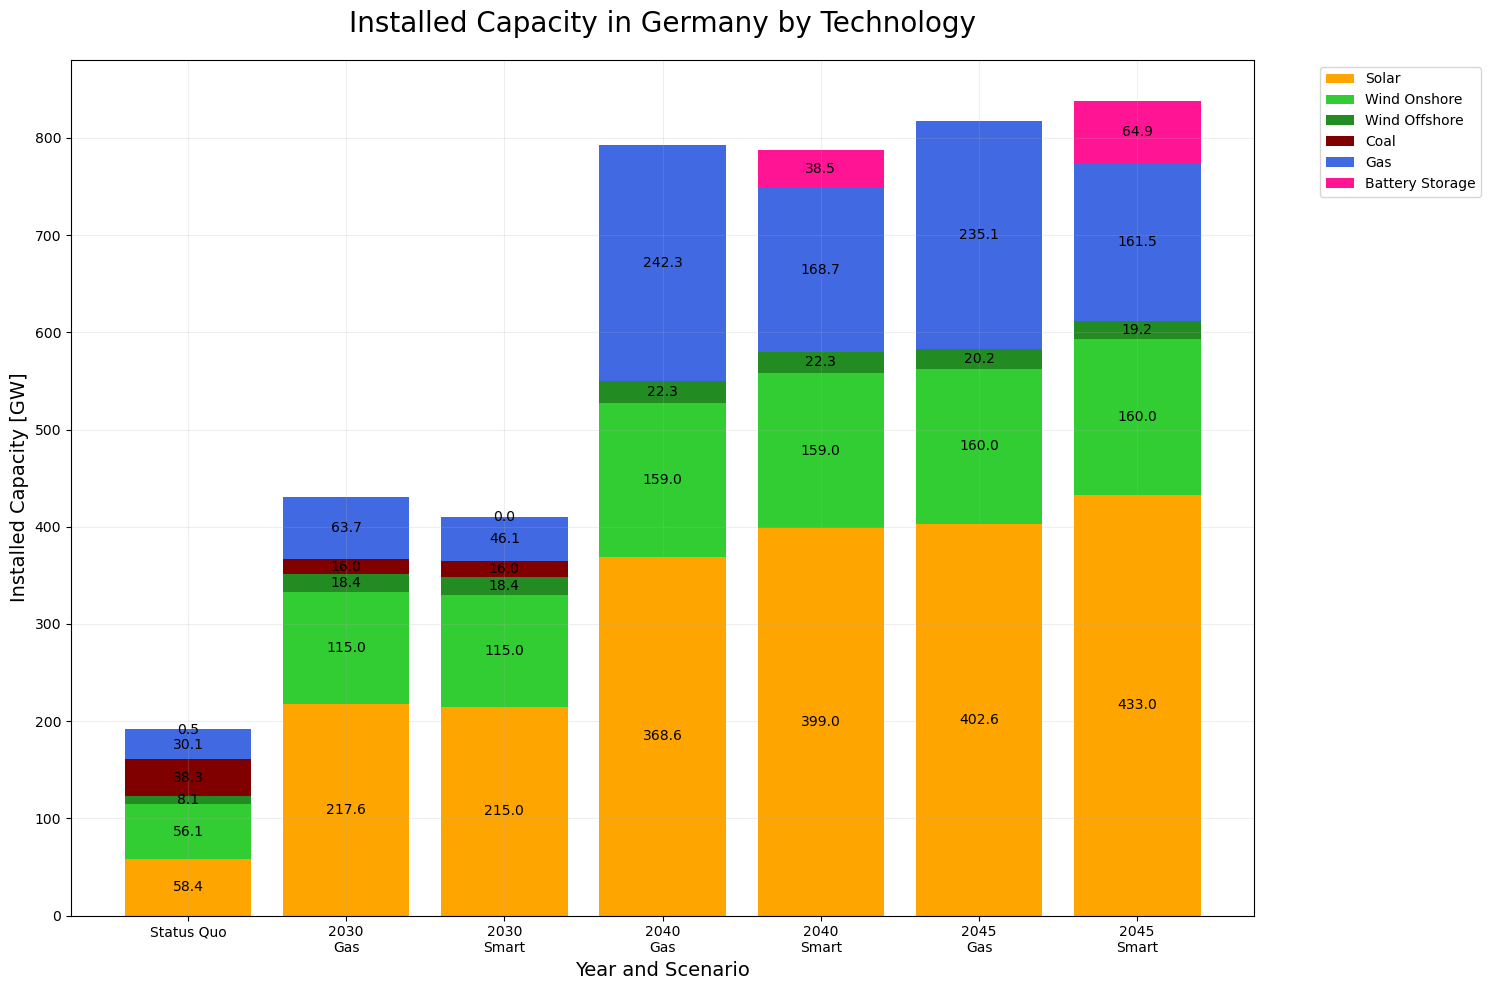


Installed Capacity Summary for GAS scenario:
            Solar (GW)  Wind Onshore (GW)  Wind Offshore (GW)  Coal (GW)  \
status-quo       58.40               56.1                8.10       38.3   
2030            217.61              115.0               18.36       16.0   
2040            368.62              159.0               22.34        0.0   
2045            402.61              160.0               20.16        0.0   

            Gas (GW)  Battery Storage (GW)  Total Renewable (GW)  \
status-quo     30.10                   0.5                122.60   
2030           63.70                   0.0                350.98   
2040          242.35                   0.0                549.95   
2045          235.14                   0.0                582.77   

            Total Conventional (GW)  Renewable Share (%)  
status-quo                    68.40                64.19  
2030                          79.70                81.49  
2040                         242.35                69.4

In [2]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def analyze_installed_capacity(network_dir, years, scenarios):
    """
    Analyze and visualize the optimized installed capacity of generators and storage.
    """
    # Define status quo capacities
    status_quo = {
        'Solar': 58.4 * 1000,
        'Wind Onshore': 56.1 * 1000,
        'Wind Offshore': 8.1 * 1000,
        'Coal': 38.3 * 1000,
        'Gas': 30.1 * 1000,
        'Battery Storage': 0.5 * 1000
    }
    
    # Create dictionary to store data for each scenario
    scenario_data = {}
    
    # Process status quo and scenarios
    for scenario in ['status-quo'] + scenarios:
        capacity_data = {}
        
        if scenario == 'status-quo':
            capacity_data = status_quo
        else:
            for year in years:
                network_file = f"{scenario}_s_27_CLL-CCL-1H_1H_{year}.nc"
                network_path = f"{network_dir}/{network_file}"
                
                n = pypsa.Network(network_path)
                german_buses = n.buses[n.buses.index.str.startswith('DE')].index
                
                # Initialize capacity dictionary for this year
                capacities = {}
                
                # Get German generators
                german_gens = n.generators[n.generators.bus.isin(german_buses)]
                
                # Calculate capacities for different technologies
                capacities['Solar'] = german_gens[
                    german_gens.carrier.isin(['solar', 'solar rooftop', 'solar-hsat'])
                ].p_nom_opt.sum()
                
                capacities['Wind Onshore'] = german_gens[
                    german_gens.carrier == 'onwind'
                ].p_nom_opt.sum()
                
                capacities['Wind Offshore'] = german_gens[
                    german_gens.carrier.isin(['offwind-ac', 'offwind-dc', 'offwind-float'])
                ].p_nom_opt.sum()
                
                german_links = n.links[
                    n.links.bus0.isin(german_buses) | 
                    n.links.bus1.isin(german_buses)
                ]
                
                capacities['Coal'] = german_links[
                    german_links.carrier.isin(['coal', 'lignite'])
                ].p_nom_opt.sum()
                
                capacities['Gas'] = german_links[
                    german_links.carrier.isin(['CCGT', 'OCGT'])
                ].p_nom_opt.sum()
                
                capacities['Battery Storage'] = german_links[
                    german_links.carrier.isin(['battery charger', 'battery discharger', 
                                             'home battery charger', 'home battery discharger'])
                ].p_nom_opt.sum()
                
                capacity_data[year] = capacities
        
        scenario_data[scenario] = capacity_data

    # Create visualization
    plt.figure(figsize=(15, 10))
    
    # Define colors for different technologies
    tech_colors = {
        'Solar': '#FFA500',  # Orange
        'Wind Onshore': '#32CD32',  # Lime Green
        'Wind Offshore': '#228B22',  # Forest Green
        'Coal': '#800000',  # Maroon
        'Gas': '#4169E1',  # Royal Blue
        'Battery Storage': '#FF1493'  # Deep Pink
    }
    
    # Prepare data for stacked bar chart
    technologies = list(tech_colors.keys())
    x_labels = []
    data_matrix = []
    
    # Add status quo
    x_labels.append('Status Quo')
    status_quo_values = [status_quo[tech]/1000 for tech in technologies]  # Convert to GW
    data_matrix.append(status_quo_values)
    
    # Add scenario data for each year
    for year in years:
        for scenario in scenarios:
            if year in scenario_data[scenario]:
                x_labels.append(f'{year}\n{scenario.capitalize()}')
                year_values = [scenario_data[scenario][year][tech]/1000 for tech in technologies]
                data_matrix.append(year_values)
    
    # Convert to numpy array for easier manipulation
    data_matrix = np.array(data_matrix).T
    
    # Create stacked bar chart
    bottom = np.zeros(len(x_labels))
    bars = []
    for i, tech in enumerate(technologies):
        bars.append(plt.bar(x_labels, data_matrix[i], bottom=bottom, 
                          label=tech, color=tech_colors[tech]))
        bottom += data_matrix[i]
    
    # Customize plot
    plt.title('Installed Capacity in Germany by Technology', fontsize=20, pad=20)
    plt.xlabel('Year and Scenario', fontsize=14)
    plt.ylabel('Installed Capacity [GW]', fontsize=14)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=0)
    
    # Add legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add grid
    plt.grid(True, alpha=0.2)
    
    # Add value labels on the bars
    for i in range(len(technologies)):
        for j in range(len(x_labels)):
            if data_matrix[i][j] > 0:  # Only add label if value is significant
                # Calculate the middle position of each segment
                height = data_matrix[i][j]
                bottom_pos = sum(data_matrix[:i, j])
                middle_pos = bottom_pos + height/2
                
                plt.text(j, middle_pos, f'{data_matrix[i][j]:.1f}',
                        ha='center', va='center')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save plots
    for format in ['png', 'pdf', 'svg']:
        plt.savefig(f'Installed_capacity_stacked_plot.{format}',
                    dpi=300,
                    bbox_inches='tight',
                    pad_inches=0.2,
                    format=format)
    
    plt.show()
    
    # Create summary tables for each scenario
    summary_tables = {}
    for scenario in scenarios:
        years_data = ['status-quo'] + years
        summary_table = pd.DataFrame(index=years_data)
        
        # Add status quo data
        for tech in technologies:
            summary_table.loc['status-quo', f'{tech} (GW)'] = status_quo[tech] / 1000
        
        # Add scenario data
        for year in years:
            if year in scenario_data[scenario]:
                for tech in technologies:
                    summary_table.loc[year, f'{tech} (GW)'] = (
                        scenario_data[scenario][year][tech] / 1000
                    )
        
        # Calculate totals and shares
        summary_table['Total Renewable (GW)'] = (
            summary_table['Solar (GW)'] + 
            summary_table['Wind Onshore (GW)'] + 
            summary_table['Wind Offshore (GW)']
        )
        
        summary_table['Total Conventional (GW)'] = (
            summary_table['Coal (GW)'] + 
            summary_table['Gas (GW)']
        )
        
        summary_table['Renewable Share (%)'] = (
            summary_table['Total Renewable (GW)'] / 
            (summary_table['Total Renewable (GW)'] + summary_table['Total Conventional (GW)']) * 100
        )
        
        summary_tables[scenario] = summary_table
        
        print(f"\nInstalled Capacity Summary for {scenario.upper()} scenario:")
        print(summary_table.round(2))
    
    return scenario_data, summary_tables

# Run the analysis
network_dir = "/home/mohsen/PycharmProjects/PyPSA-Eur/pypsa-eur-flexibility/results/scenario/gas-smart-myopic/networks"
years = [2030, 2040, 2045]
scenarios = ['gas', 'smart']

scenario_data, scenario_summaries = analyze_installed_capacity(network_dir, years, scenarios)


Processing gas scenario, year 2030


INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Checking EV components:
Number of EV chargers: 27
Number of V2G: 0
Number of EV batteries: 0
Number of EV loads: 27
Found EV component: bev charger / de0 0 bev charger-2030
Found EV component: bev charger / de0 1 bev charger-2030
Found EV component: bev charger / de0 2 bev charger-2030
Found EV component: bev charger / de0 3 bev charger-2030
Found EV component: bev charger / de0 4 bev charger-2030
Found EV component: bev charger / de0 5 bev charger-2030
Found EV component: bev charger / de0 6 bev charger-2030
Found EV component: bev charger / de0 7 bev charger-2030
Found EV component: dc / relation/16213216-525-dc-reversed
Found EV component: dc / relation/2505320-400-dc-reversed
Found EV component: dc / relation/3918230-450-dc-reversed
Found EV component: dc / relation/8193755-320-dc-reversed
Found EV component: dc / tyndp2020_1_nep_dc3-reversed
Found EV component: dc / tyndp2020_2_nep_dc4-reversed
Found EV component: dc / tyndp2020_10-reversed
Found EV component: dc / tyndp2020_22-r

INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Checking EV components:
Number of EV chargers: 27
Number of V2G: 0
Number of EV batteries: 0
Number of EV loads: 27
Found EV component: bev charger / de0 0 bev charger-2040
Found EV component: bev charger / de0 1 bev charger-2040
Found EV component: bev charger / de0 2 bev charger-2040
Found EV component: bev charger / de0 3 bev charger-2040
Found EV component: bev charger / de0 4 bev charger-2040
Found EV component: bev charger / de0 5 bev charger-2040
Found EV component: bev charger / de0 6 bev charger-2040
Found EV component: bev charger / de0 7 bev charger-2040
Found EV component: dc / relation/16213216-525-dc-reversed
Found EV component: dc / relation/2505320-400-dc-reversed
Found EV component: dc / relation/3918230-450-dc-reversed
Found EV component: dc / relation/8193755-320-dc-reversed
Found EV component: dc / tyndp2020_1_nep_dc3-reversed
Found EV component: dc / tyndp2020_2_nep_dc4-reversed
Found EV component: dc / tyndp2020_10-reversed
Found EV component: dc / tyndp2020_22-r

...


Checking EV components:
Number of EV chargers: 27
Number of V2G: 27
Number of EV batteries: 27
Number of EV loads: 27
Found EV component: bev charger / de0 0 bev charger-2030
Found EV component: bev charger / de0 1 bev charger-2030
Found EV component: bev charger / de0 2 bev charger-2030
Found EV component: bev charger / de0 3 bev charger-2030
Found EV component: bev charger / de0 4 bev charger-2030
Found EV component: bev charger / de0 5 bev charger-2030
Found EV component: bev charger / de0 6 bev charger-2030
Found EV component: bev charger / de0 7 bev charger-2030
Found EV component: v2g / de0 0 v2g-2030
Found EV component: v2g / de0 1 v2g-2030
Found EV component: v2g / de0 2 v2g-2030
Found EV component: v2g / de0 3 v2g-2030
Found EV component: v2g / de0 4 v2g-2030
Found EV component: v2g / de0 5 v2g-2030
Found EV component: v2g / de0 6 v2g-2030
Found EV component: v2g / de0 7 v2g-2030
Found EV component: dc / relation/16213216-525-dc-reversed
Found EV component: dc / relation/2505

INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Checking EV components:
Number of EV chargers: 27
Number of V2G: 27
Number of EV batteries: 27
Number of EV loads: 27
Found EV component: bev charger / de0 0 bev charger-2040
Found EV component: bev charger / de0 1 bev charger-2040
Found EV component: bev charger / de0 2 bev charger-2040
Found EV component: bev charger / de0 3 bev charger-2040
Found EV component: bev charger / de0 4 bev charger-2040
Found EV component: bev charger / de0 5 bev charger-2040
Found EV component: bev charger / de0 6 bev charger-2040
Found EV component: bev charger / de0 7 bev charger-2040
Found EV component: v2g / de0 0 v2g-2040
Found EV component: v2g / de0 1 v2g-2040
Found EV component: v2g / de0 2 v2g-2040
Found EV component: v2g / de0 3 v2g-2040
Found EV component: v2g / de0 4 v2g-2040
Found EV component: v2g / de0 5 v2g-2040
Found EV component: v2g / de0 6 v2g-2040
Found EV component: v2g / de0 7 v2g-2040
Found EV component: dc / relation/16213216-525-dc-reversed
Found EV component: dc / relation/2505

INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Checking EV components:
Number of EV chargers: 27
Number of V2G: 27
Number of EV batteries: 27
Number of EV loads: 27
Found EV component: bev charger / de0 0 bev charger-2045
Found EV component: bev charger / de0 1 bev charger-2045
Found EV component: bev charger / de0 2 bev charger-2045
Found EV component: bev charger / de0 3 bev charger-2045
Found EV component: bev charger / de0 4 bev charger-2045
Found EV component: bev charger / de0 5 bev charger-2045
Found EV component: bev charger / de0 6 bev charger-2045
Found EV component: bev charger / de0 7 bev charger-2045
Found EV component: v2g / de0 0 v2g-2045
Found EV component: v2g / de0 1 v2g-2045
Found EV component: v2g / de0 2 v2g-2045
Found EV component: v2g / de0 3 v2g-2045
Found EV component: v2g / de0 4 v2g-2045
Found EV component: v2g / de0 5 v2g-2045
Found EV component: v2g / de0 6 v2g-2045
Found EV component: v2g / de0 7 v2g-2045
Found EV component: dc / relation/16213216-525-dc-reversed
Found EV component: dc / relation/2505

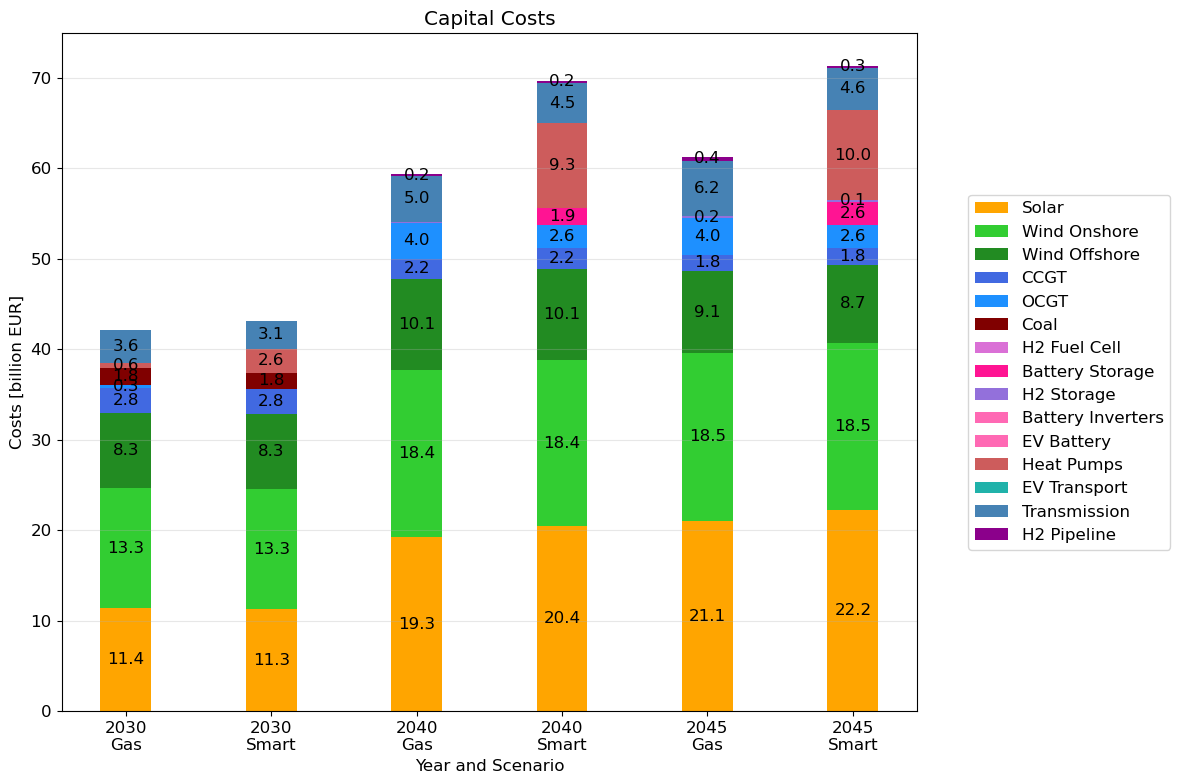

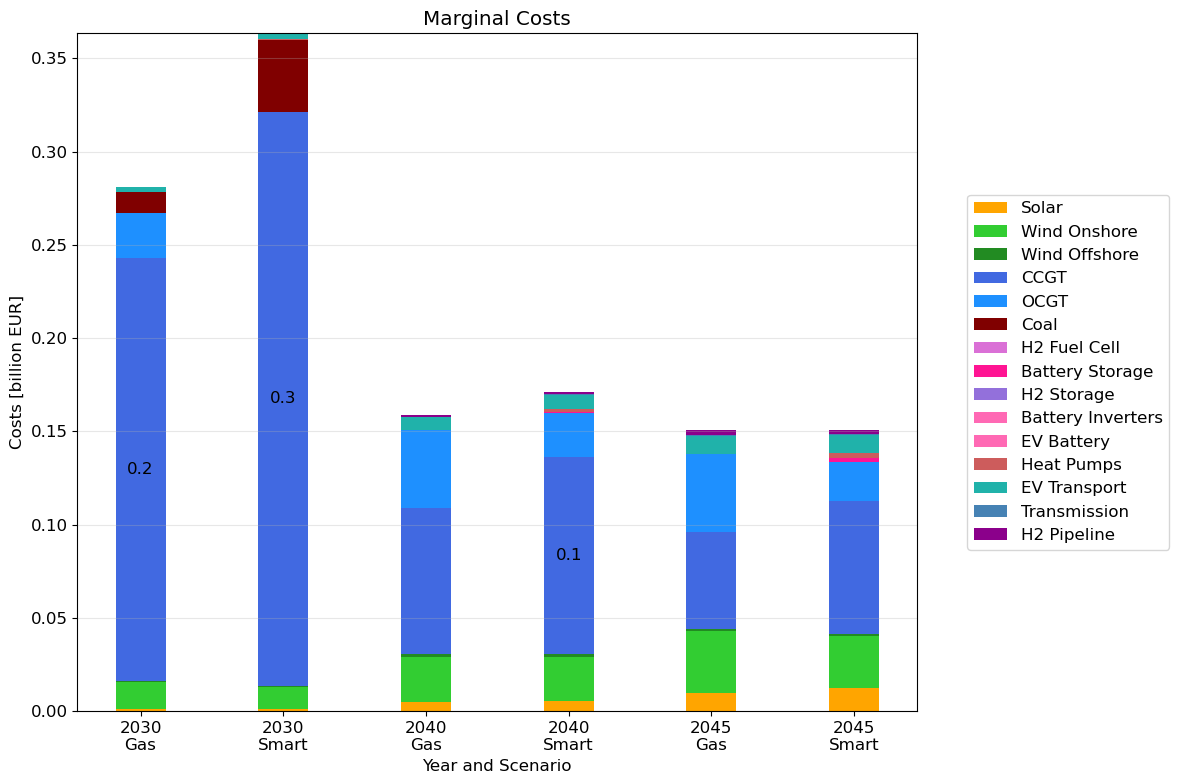

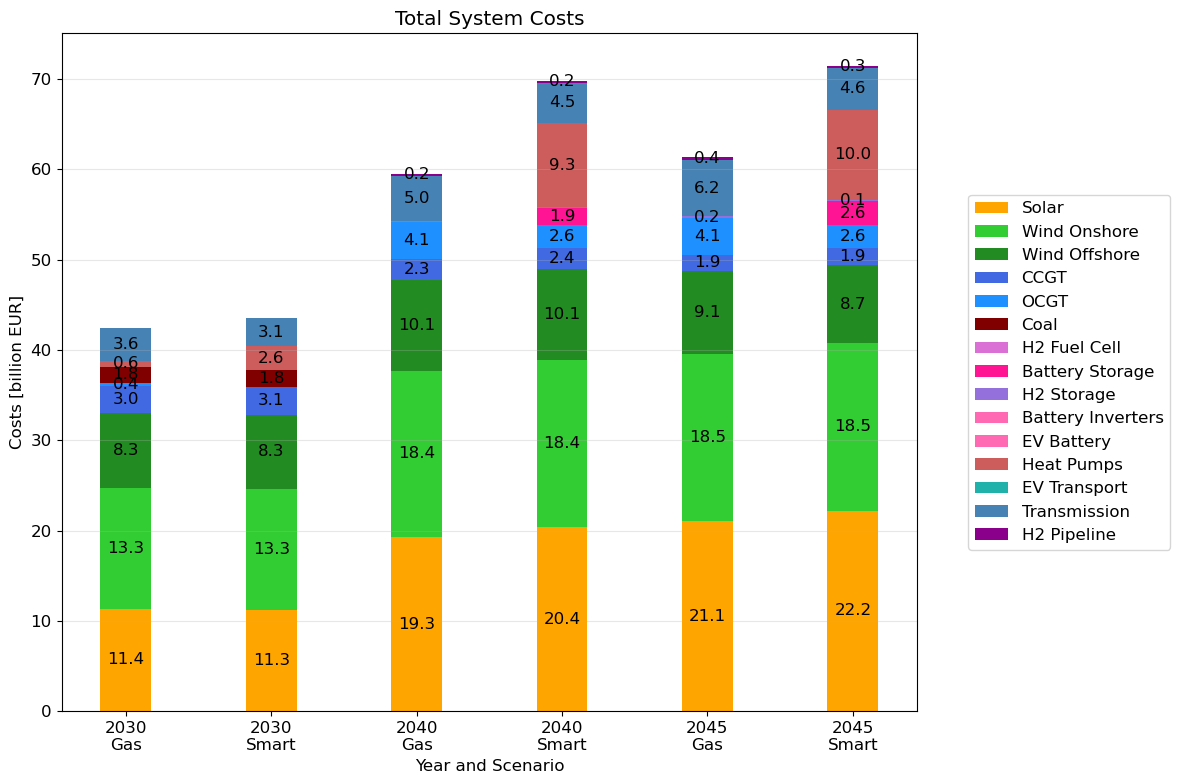

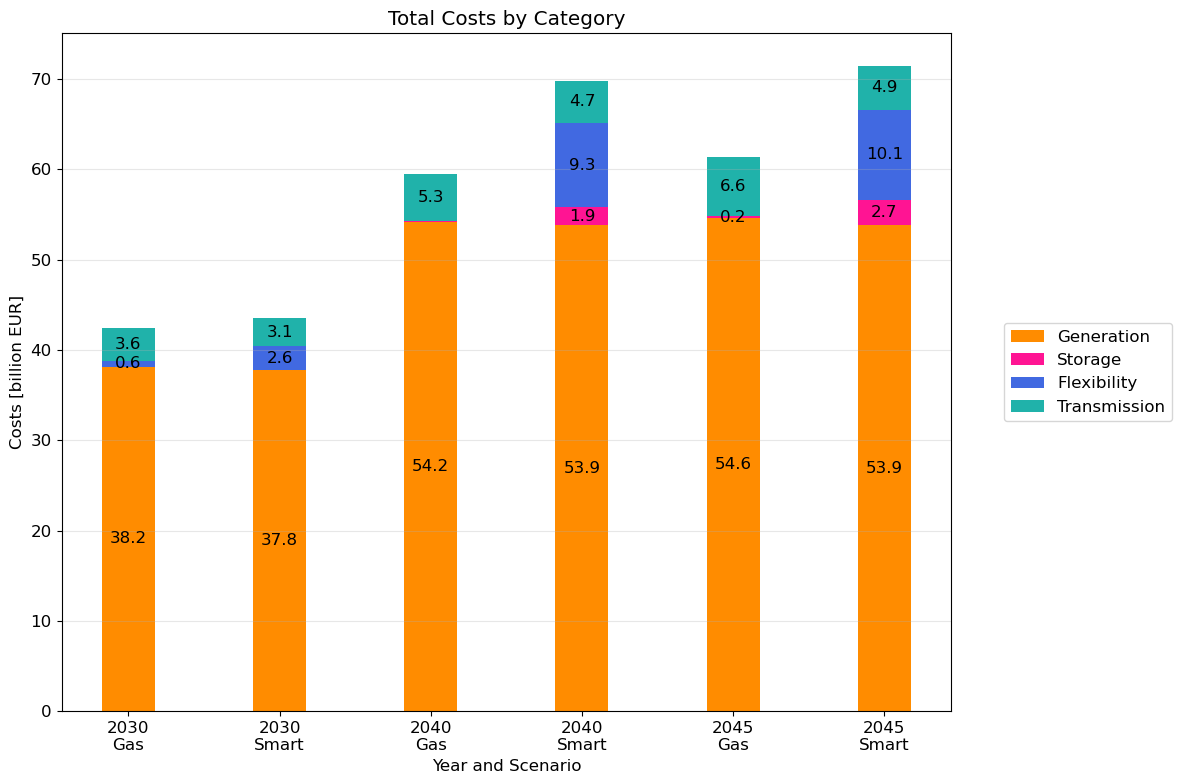

In [16]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import traceback

# Updated categories dictionary
categories = {
    'Generation': {
        'Solar': ['solar'],
        'Wind Onshore': ['onwind'],
        'Wind Offshore': ['offwind'],
        'CCGT': ['CCGT'],
        'OCGT': ['OCGT'],
        'Coal': ['coal', 'lignite'],
        'H2 Fuel Cell': ['H2 Fuel Cell'],
    },
    'Storage': {
        'Battery Storage': ['battery', 'home battery'],  # Remove EV battery from here
        'H2 Storage': ['H2 Store'],
        'Battery Inverters': ['battery charger', 'battery discharger', 
                            'home battery charger', 'home battery discharger'],
        'EV Battery': ['EV battery'],  # Add as separate category
    },
    'Flexibility': {
        'Heat Pumps': ['heat pump'],
        'EV Transport': ['BEV charger', 'V2G', 'land transport EV'],
    },
    'Transmission': {
        'Transmission': ['DC', 'AC'],
        'H2 Pipeline': ['H2 pipeline'],
    }
}

# Updated color schemes
detailed_colors = {
    # Generation
    'Solar': '#FFA500',          # Orange
    'Wind Onshore': '#32CD32',   # Lime Green
    'Wind Offshore': '#228B22',  # Forest Green
    'CCGT': '#4169E1',          # Royal Blue
    'OCGT': '#1E90FF',          # Dodger Blue
    'Coal': '#800000',          # Maroon
    'H2 Fuel Cell': '#DA70D6',  # Orchid

    # Storage
    'Battery Storage': '#FF1493',# Deep Pink
    'H2 Storage': '#9370DB',    # Medium Purple
    'Battery Inverters': '#FF69B4', # Hot Pink
    'EV Battery': '#FF69B4',

    # Flexibility
    #'H2 Electrolysis': '#FF4500',# Orange Red
    'Heat Pumps': '#CD5C5C',    # Indian Red
    'EV Transport': '#20B2AA',   # Light Sea Green

    # Transmission
    'Transmission': '#4682B4',   # Steel Blue
    'H2 Pipeline': '#8B008B'    # Dark Magenta
}

aggregated_colors = {
    'Generation': '#FF8C00',     # Dark Orange
    'Storage': '#FF1493',        # Deep Pink
    'Flexibility': '#4169E1',    # Royal Blue
    'Transmission': '#20B2AA'    # Light Sea Green
}

def calculate_detailed_costs(n, german_buses):
    """Calculate capital and marginal costs with detailed categorization."""
    
    # Initialize cost dictionaries
    capital_costs = {cat: 0 for subdict in categories.values() for cat in subdict.keys()}
    marginal_costs = {cat: 0 for subdict in categories.values() for cat in subdict.keys()}

    
    def process_component(component, comp_type):
        """
        Process component to determine its category.
        """
        carrier = str(component.carrier).lower() if hasattr(component, 'carrier') else ''
        name = str(component.name).lower() if hasattr(component, 'name') else ''
        
        # Direct matching for specific components
        if 'H2 Store' in carrier or 'H2 Store' in name:
            return 'H2 Storage', 'Storage'
        #elif 'H2 Electrolysis' in carrier or 'H2 Electrolysis' in name:
            #return 'H2 Electrolysis', 'Flexibility'
        elif 'H2 Fuel Cell' in carrier or 'H2 Fuel Cell' in name:
            return 'H2 Fuel Cell', 'Generation'
        elif 'H2 pipeline' in carrier or 'H2 pipeline' in name:
            return 'H2 Pipeline', 'Transmission'
        elif any(ev in carrier or ev in name for ev in ['bev', 'ev', 'electric vehicle', 'v2g']):
            print(f"Found EV component: {carrier} / {name}")  # Debug print
            return 'EV Transport', 'Flexibility'
        
        # General matching for other components
        for main_cat, subcat_dict in categories.items():
            for subcat, keywords in subcat_dict.items():
                if any(keyword.lower() in carrier for keyword in keywords) or \
                   any(keyword.lower() in name for keyword in keywords):
                    return subcat, main_cat
        return None, None

    try:

        # Add at the start of the try block
        print("\nChecking EV components:")
        print(f"Number of EV chargers: {len(n.links[n.links.carrier == 'BEV charger'])}")
        print(f"Number of V2G: {len(n.links[n.links.carrier == 'V2G'])}")
        print(f"Number of EV batteries: {len(n.stores[n.stores.carrier == 'EV battery'])}")
        print(f"Number of EV loads: {len(n.loads[n.loads.carrier == 'land transport EV'])}")
        
        # Process generators
        generators = n.generators[n.generators.bus.isin(german_buses)]
        for idx, gen in generators.iterrows():
            subcat, main_cat = process_component(gen, 'generator')
            if subcat:
                capital_costs[subcat] += gen.capital_cost * gen.p_nom_opt
                marginal_costs[subcat] += gen.marginal_cost * n.generators_t.p[idx].sum()
        
        # Process links
        links = n.links[n.links.bus0.isin(german_buses) | n.links.bus1.isin(german_buses)]
        for idx, link in links.iterrows():
            subcat, main_cat = process_component(link, 'link')
            if subcat:
                capital_costs[subcat] += link.capital_cost * link.p_nom_opt
                if hasattr(n.links_t, 'p0') and idx in n.links_t.p0:
                    marginal_costs[subcat] += link.marginal_cost * abs(n.links_t.p0[idx].sum())

        # Process EV chargers and V2G
        ev_links = n.links[
            (n.links.bus0.isin(german_buses)) & 
            ((n.links.carrier == 'BEV charger') | (n.links.carrier == 'V2G'))
        ]
        for idx, link in ev_links.iterrows():
            capital_costs['EV Transport'] += link.capital_cost * link.p_nom_opt
            if hasattr(n.links_t, 'p0') and idx in n.links_t.p0:
                marginal_costs['EV Transport'] += link.marginal_cost * abs(n.links_t.p0[idx].sum())

        # Process EV chargers and V2G
        ev_links = n.links[
            (n.links.bus0.isin(german_buses)) & 
            ((n.links.carrier == 'BEV charger') | (n.links.carrier == 'V2G'))
        ]
        for idx, link in ev_links.iterrows():
            print(f"\nProcessing EV link: {link.carrier}")  # Debug print
            print(f"Capital cost: {link.capital_cost}")
            print(f"p_nom_opt: {link.p_nom_opt}")
            capital_costs['EV Transport'] += link.capital_cost * link.p_nom_opt
            if hasattr(n.links_t, 'p0') and idx in n.links_t.p0:
                marginal_costs['EV Transport'] += link.marginal_cost * abs(n.links_t.p0[idx].sum())

        # Process EV batteries
        ev_stores = n.stores[
            (n.stores.bus.isin(german_buses)) & 
            (n.stores.carrier == 'EV battery')
        ]
        for idx, store in ev_stores.iterrows():
            print(f"\nProcessing EV battery store: {store.carrier}")  # Debug print
            print(f"Capital cost: {store.capital_cost}")
            print(f"e_nom_opt: {store.e_nom_opt}")
            capital_costs['EV Battery'] += store.capital_cost * store.e_nom_opt
            if hasattr(store, 'marginal_cost'):
                if hasattr(n.stores_t, 'p') and idx in n.stores_t.p:
                    marginal_costs['EV Battery'] += store.marginal_cost * abs(n.stores_t.p[idx].sum())

        # Process EV loads
        ev_loads = n.loads[
            (n.loads.bus.isin(german_buses)) & 
            (n.loads.carrier == 'land transport EV')
        ]
        for idx, load in ev_loads.iterrows():
            print(f"\nProcessing EV load: {load.carrier}")  # Debug print
            if hasattr(load, 'capital_cost'):
                print(f"Capital cost: {load.capital_cost}")
                print(f"p_nom: {load.p_nom}")
                capital_costs['EV Transport'] += load.capital_cost * load.p_nom
        # Debug prints for EV components
        print("\nEV-related costs found:")
        print(f"EV Transport capital costs: {capital_costs['EV Transport']}")
        print(f"EV Transport marginal costs: {marginal_costs['EV Transport']}")
        print(f"EV Battery capital costs: {capital_costs['EV Battery']}")
        print(f"EV Battery marginal costs: {marginal_costs['EV Battery']}")
        
        # Process stores
        stores = n.stores[n.stores.bus.isin(german_buses)]
        for idx, store in stores.iterrows():
            subcat, main_cat = process_component(store, 'store')
            if subcat:
                capital_costs[subcat] += store.capital_cost * store.e_nom_opt
                if hasattr(store, 'marginal_cost') and store.marginal_cost > 0:
                    if hasattr(n.stores_t, 'p') and idx in n.stores_t.p:
                        marginal_costs[subcat] += store.marginal_cost * abs(n.stores_t.p[idx].sum())
        
        # Process lines
        lines = n.lines[n.lines.bus0.isin(german_buses) | n.lines.bus1.isin(german_buses)]
        capital_costs['Transmission'] += (lines.capital_cost * lines.s_nom_opt).sum()
        
        # Debug print for component costs
        print("\nComponent costs found (before scaling):")
        for category, cost in capital_costs.items():
            if cost > 0:
                print(f"{category} capital cost: {cost:.2f}")
        
        # Convert to billion EUR
        scale_factor = 1e-9
        capital_costs = {k: v * scale_factor for k, v in capital_costs.items()}
        marginal_costs = {k: v * scale_factor for k, v in marginal_costs.items()}
        
        # Calculate total costs
        total_costs = {}
        for k in capital_costs.keys():
            total_costs[k] = capital_costs[k] + marginal_costs[k]
        
        # Calculate aggregated costs
        aggregated_costs = {main_cat: 0 for main_cat in categories.keys()}
        for subcat, value in total_costs.items():
            for main_cat, subcat_dict in categories.items():
                if subcat in subcat_dict:
                    aggregated_costs[main_cat] += value
        
        # Convert to pandas Series
        capital_costs_series = pd.Series(capital_costs)
        marginal_costs_series = pd.Series(marginal_costs)
        total_costs_series = pd.Series(total_costs)
        aggregated_costs_series = pd.Series(aggregated_costs)
        
        return (capital_costs_series, marginal_costs_series, 
                total_costs_series, aggregated_costs_series)
    
    except Exception as e:
        print(f"Error in calculate_detailed_costs: {str(e)}")
        traceback.print_exc()  # This will print the full error traceback
        return None, None, None, None

def plot_cost_chart(df_gas, df_smart, title, output_dir, colors):
    """Create a single cost type plot with yearly stacked bars for both scenarios."""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Calculate x positions
    x = np.arange(len(df_gas.columns))  # Years
    width = 0.35  # Width of the bars
    
    # Create list of all years with scenarios
    x_labels = []
    for year in df_gas.columns:
        x_labels.extend([f'{year}\nGas', f'{year}\nSmart'])
    
    # Prepare data for plotting
    plot_data = {'Gas': df_gas, 'Smart': df_smart}
    x_positions = np.arange(len(x_labels))
    
    # Create stacked bar chart
    bottom = np.zeros(len(x_labels))
    for component in df_gas.index:
        # Prepare values for both scenarios
        values = []
        for year in df_gas.columns:
            values.extend([df_gas.loc[component, year], df_smart.loc[component, year]])
        
        ax.bar(x_positions, values, width, bottom=bottom,
               label=component, color=colors.get(component, '#333333'))
        bottom += values
    
    # Customize plot
    ax.set_ylabel("Costs [billion EUR]")
    ax.set_xlabel("Year and Scenario")
    ax.set_title(title)
    
    # Set x-ticks and labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels)
    
    # Add grid
    ax.grid(axis="y", alpha=0.3)
    
    # Add legend
    ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
    
    # Add value labels
    bottom = np.zeros(len(x_labels))
    for component in df_gas.index:
        values = []
        for year in df_gas.columns:
            values.extend([df_gas.loc[component, year], df_smart.loc[component, year]])
            
        # Only add labels for significant values
        for i, v in enumerate(values):
            if v > 0.1:  # Only label if value is greater than 0.1
                ax.text(i, bottom[i] + v/2, f'{v:.1f}',
                       ha='center', va='center')
        bottom += values
    
    plt.tight_layout()
    
    # Save plot
    filename = title.lower().replace(' ', '_')
    fig.savefig(os.path.join(output_dir, f'{filename}.png'), 
                dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(output_dir, f'{filename}.pdf'), 
                bbox_inches='tight')
    
    return fig

def plot_all_costs(network_dir, output_dir, years):
    """Create four separate plots for costs."""
    
    # Store results for each scenario and year
    scenarios = ['gas', 'smart']
    results = {scenario: {'capital': [], 'marginal': [], 'total': [], 'aggregated': []} 
              for scenario in scenarios}
    
    # Process each scenario and year
    for scenario in scenarios:
        for year in years:
            print(f"\nProcessing {scenario} scenario, year {year}")
            network_file = f"{scenario}_s_27_CLL-CCL-1H_1H_{year}.nc"
            network_path = os.path.join(network_dir, network_file)
            
            try:
                n = pypsa.Network(network_path)
                german_buses = n.buses[n.buses.index.str.startswith('DE')].index
                
                capital, marginal, total, aggregated = calculate_detailed_costs(n, german_buses)
                
                if all(x is not None for x in [capital, marginal, total, aggregated]):
                    for series, result_type in zip([capital, marginal, total, aggregated],
                                                 ['capital', 'marginal', 'total', 'aggregated']):
                        series.name = year
                        results[scenario][result_type].append(series)
                
            except Exception as e:
                print(f"Error processing {scenario} scenario, year {year}: {str(e)}")
                continue
    
    # Check if we have any results
    if not any(results[scenario]['capital'] for scenario in scenarios):
        print("No results to plot!")
        return
    
    # Create DataFrames and plots
    dfs = {}
    for scenario in scenarios:
        if results[scenario]['capital']:  # Check if we have results
            dfs[scenario] = {
                'capital': pd.concat(results[scenario]['capital'], axis=1),
                'marginal': pd.concat(results[scenario]['marginal'], axis=1),
                'total': pd.concat(results[scenario]['total'], axis=1),
                'aggregated': pd.concat(results[scenario]['aggregated'], axis=1)
            }
    
    # Create plots if we have data
    if dfs:
        plot_cost_chart(dfs['gas']['capital'], dfs['smart']['capital'], 
                       "Capital Costs", output_dir, detailed_colors)
        plot_cost_chart(dfs['gas']['marginal'], dfs['smart']['marginal'], 
                       "Marginal Costs", output_dir, detailed_colors)
        plot_cost_chart(dfs['gas']['total'], dfs['smart']['total'], 
                       "Total System Costs", output_dir, detailed_colors)
        plot_cost_chart(dfs['gas']['aggregated'], dfs['smart']['aggregated'], 
                       "Total Costs by Category", output_dir, aggregated_colors)
        
        # Print totals
        for scenario in scenarios:
            print(f"\nTotal costs for {scenario} scenario by year [billion EUR]:")
            print(dfs[scenario]['total'].sum())
            print(f"\nTotal costs for {scenario} scenario by category [billion EUR]:")
            print(dfs[scenario]['aggregated'].sum())

# Usage
if __name__ == "__main__":
    network_dir = "/home/mohsen/PycharmProjects/PyPSA-Eur/pypsa-eur-flexibility/results/scenario/gas-smart-myopic/networks"
    output_dir = "/home/mohsen/PycharmProjects/PyPSA-Eur/pypsa-eur-flexibility/results/scenario/gas-smart-myopic/germany_statistics_output"
    years = [2030, 2040, 2045]
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Generate plots
    plot_all_costs(network_dir, output_dir, years)

INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/tmp/ipykernel_109746/3993379396.py:113: UserW

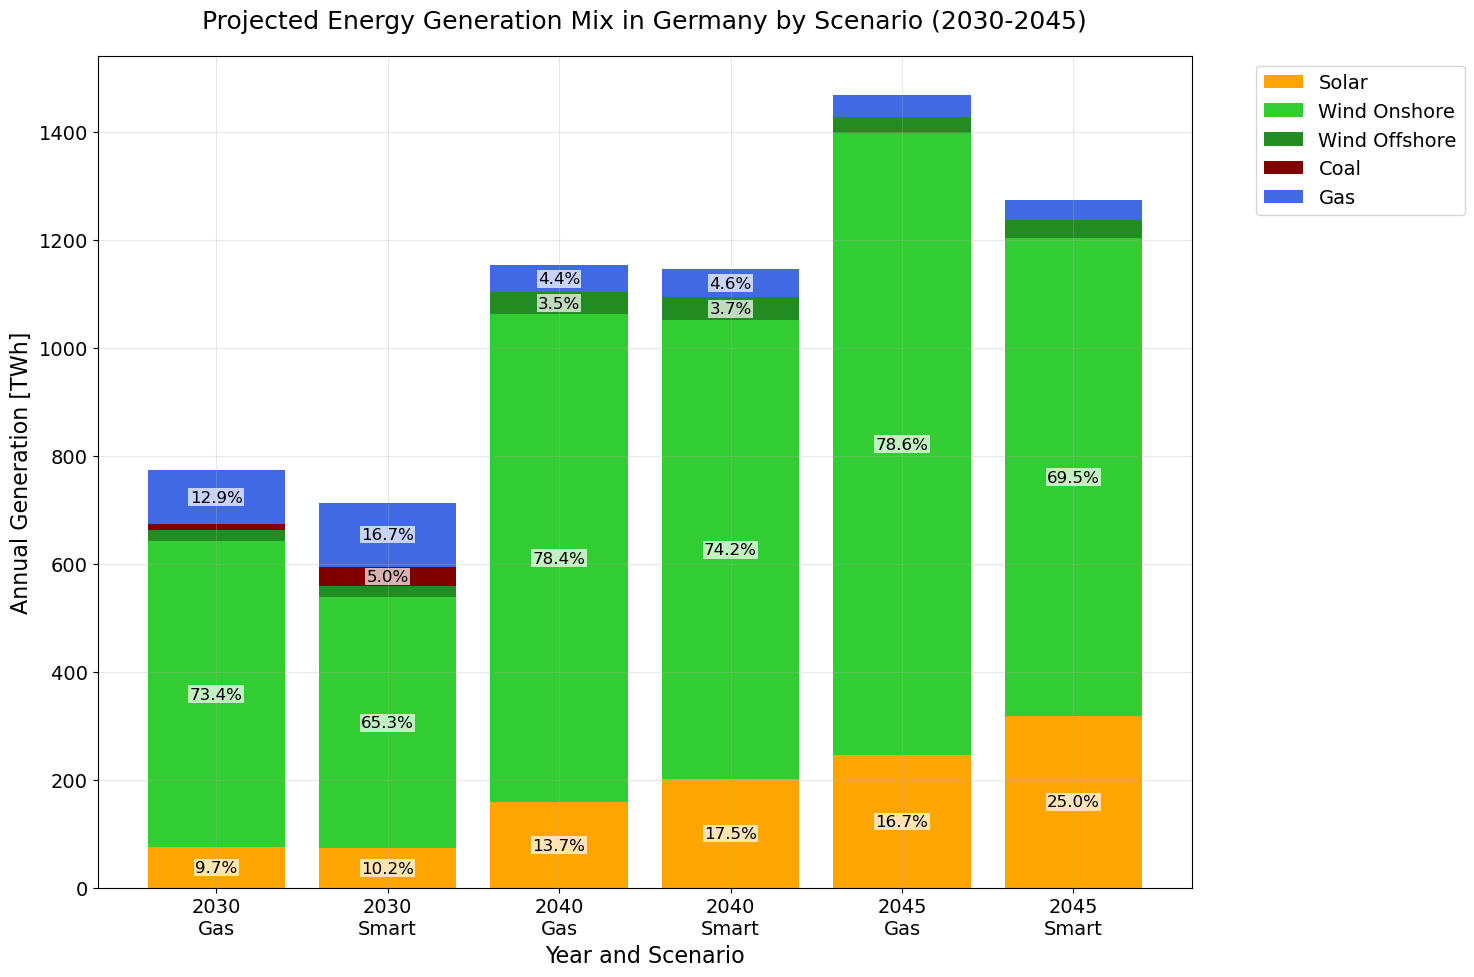


Summary Statistics for GAS scenario:
      Total Generation (TWh)  Renewable Share (%)  Conventional Share (%)  \
2030                  773.26                85.76                   14.24   
2040                 1153.65                95.58                    4.42   
2045                 1467.63                97.23                    2.77   

      Solar (TWh)  Wind Onshore (TWh)  Wind Offshore (TWh)  Coal (TWh)  \
2030        75.14              567.36                20.62       10.26   
2040       157.91              904.61                40.09        0.00   
2045       245.14             1153.43                28.42        0.00   

      Gas (TWh)  
2030      99.89  
2040      51.04  
2045      40.64  

Summary Statistics for SMART scenario:
      Total Generation (TWh)  Renewable Share (%)  Conventional Share (%)  \
2030                  713.49                78.34                   21.66   
2040                 1145.94                95.43                    4.57   
2045         

In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def get_german_generation_data(network):
    # Get German buses
    german_buses = network.buses[network.buses.index.str.startswith('DE')].index
    
    # Process generators
    german_gens = network.generators[network.generators.bus.isin(german_buses)]
    
    # Calculate renewable generation
    renewable_gen = {
        'Solar': german_gens[german_gens.carrier.isin(['solar', 'solar rooftop', 'solar-hsat'])].index,
        'Wind Onshore': german_gens[german_gens.carrier == 'onwind'].index,
        'Wind Offshore': german_gens[german_gens.carrier.isin(['offwind-ac', 'offwind-dc', 'offwind-float'])].index
    }
    
    # Get German links
    german_links = network.links[
        network.links.bus0.isin(german_buses) | 
        network.links.bus1.isin(german_buses)
    ]
    
    # Calculate conventional generation
    conventional_gen = {
        'Coal': german_links[german_links.carrier.isin(['coal', 'lignite'])].index,
        'Gas': german_links[german_links.carrier.isin(['CCGT', 'OCGT'])].index
    }
    
    # Calculate annual generation for each source
    generation_data = {}
    
    # Renewable generation
    for source, indices in renewable_gen.items():
        if len(indices) > 0:
            generation_data[source] = network.generators_t.p[indices].sum().sum()
        else:
            generation_data[source] = 0
            
    # Conventional generation
    for source, indices in conventional_gen.items():
        if len(indices) > 0:
            generation_data[source] = network.links_t.p0[indices].sum().sum()
        else:
            generation_data[source] = 0
            
    return pd.Series(generation_data)

def create_energy_balance_charts(network_dir, years, scenarios):
    # Store results for each scenario
    energy_balance = {scenario: pd.DataFrame() for scenario in scenarios}
    
    # Process each scenario and year
    for scenario in scenarios:
        for year in years:
            network_file = f"{scenario}_s_27_CLL-CCL-1H_1H_{year}.nc"
            network_path = f"{network_dir}/{network_file}"
            
            try:
                n = pypsa.Network(network_path)
                energy_balance[scenario][year] = get_german_generation_data(n)
            except Exception as e:
                print(f"Error processing {scenario} scenario, year {year}: {str(e)}")
    
    # Create the stacked bar chart
    plt.figure(figsize=(15, 10))
    plt.rcParams.update({'font.size': 14})
    
    # Define colors for different sources
    colors = {
        'Solar': '#FFA500',  # Orange
        'Wind Onshore': '#32CD32',  # Lime Green
        'Wind Offshore': '#228B22',  # Forest Green
        'Coal': '#800000',  # Maroon
        'Gas': '#4169E1'  # Royal Blue
    }
    
    # Create x-axis labels
    x_labels = []
    x_positions = []
    pos = 0
    for year in years:
        for scenario in scenarios:
            x_labels.append(f'{year}\n{scenario.capitalize()}')
            x_positions.append(pos)
            pos += 1
    
    # Create bottom values for stacking
    bottom = np.zeros(len(x_positions))
    
    # Plot each energy source
    for source in energy_balance[scenarios[0]].index:
        values = []
        for year in years:
            for scenario in scenarios:
                values.append(energy_balance[scenario][year].loc[source])
        
        plt.bar(x_positions, values, bottom=bottom, label=source, color=colors[source])
        bottom += values
    
    # Customize the plot
    plt.title('Projected Energy Generation Mix in Germany by Scenario (2030-2045)', 
             fontsize=18, pad=20)
    plt.xlabel('Year and Scenario', fontsize=16)
    plt.ylabel('Annual Generation [TWh]', fontsize=16)
    
    # Convert y-axis to TWh and increase tick label size
    ax = plt.gca()
    current_values = ax.get_yticks()
    ax.set_yticklabels([f'{x/1e6:.0f}' for x in current_values], fontsize=14)
    
    # Set x-axis ticks and labels
    plt.xticks(x_positions, x_labels, fontsize=14)
    
    # Add legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Add percentage labels on bars
    for scenario in scenarios:
        for i, year in enumerate(years):
            pos = i * len(scenarios) + scenarios.index(scenario)
            total = energy_balance[scenario][year].sum()
            height = 0
            for source in energy_balance[scenario].index:
                value = energy_balance[scenario][year].loc[source]
                if value > 0:
                    percentage = (value / total) * 100
                    if percentage > 3:  # Only show if percentage is greater than 3%
                        plt.text(pos, height + value/2, f'{percentage:.1f}%',
                                ha='center', va='center', fontsize=12,
                                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
                height += value
    
    # Adjust layout
    plt.tight_layout()
    
    # Save plots in different formats
    for format in ['png', 'pdf', 'svg']:
        plt.savefig(f'energy_generation_mix.{format}',
                    dpi=300,
                    bbox_inches='tight',
                    pad_inches=0.2,
                    format=format)
    
    plt.show()
    
    # Create summary tables for each scenario
    summary_tables = {}
    for scenario in scenarios:
        summary_table = pd.DataFrame(index=years)
        total_generation = energy_balance[scenario].sum()
        
        summary_table['Total Generation (TWh)'] = total_generation / 1e6
        summary_table['Renewable Share (%)'] = ((energy_balance[scenario].loc['Solar'] + 
                                               energy_balance[scenario].loc['Wind Onshore'] + 
                                               energy_balance[scenario].loc['Wind Offshore']) / 
                                              total_generation) * 100
        summary_table['Conventional Share (%)'] = ((energy_balance[scenario].loc['Coal'] + 
                                                  energy_balance[scenario].loc['Gas']) / 
                                                 total_generation) * 100
        
        # Add generation by source in TWh
        for source in energy_balance[scenario].index:
            summary_table[f'{source} (TWh)'] = energy_balance[scenario].loc[source] / 1e6
        
        summary_tables[scenario] = summary_table
        
        print(f"\nSummary Statistics for {scenario.upper()} scenario:")
        print(summary_table.round(2))
    
    return energy_balance, summary_tables

# Run the analysis
network_dir = "/home/mohsen/PycharmProjects/PyPSA-Eur/pypsa-eur-flexibility/results/scenario/gas-smart-myopic/networks"
years = [2030, 2040, 2045]
scenarios = ['gas', 'smart']

energy_balance, summaries = create_energy_balance_charts(network_dir, years, scenarios)


Processing gas scenario...
Processing year 2030...


INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Processing year 2040...


INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Processing year 2045...


...

Processing year 2040...


INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Processing year 2045...


INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Detailed Generation Mix - GAS scenario (TWh):
      Solar PV  Wind Onshore  Wind Offshore   Coal    Gas   Oil  Biomass  \
2030     75.14        567.36          20.62  10.26  99.89  0.01   109.09   
2040    157.91        904.61          40.09   0.00  51.04  0.00     1.74   
2045    245.14       1153.43          28.42   0.00  40.64  0.00     0.00   

      Other Renewables  Imports  Battery Discharge  
2030               0.0   124.45                0.0  
2040               0.0   168.74                0.0  
2045               0.0   181.72                0.0  

Detailed Consumption Mix - GAS scenario (TWh):
      Electricity  Battery Charging  Exports  Hydrogen Production
2030       496.13               0.0   169.38                 0.00
2040       554.12               0.0   221.38                86.98
2045       581.30               0.0   238.56               290.96

Electricity Trade Balance - GAS scenario (TWh):
      Imports  Exports  Net Trade
2030   124.45   169.38     -44.93
2040   

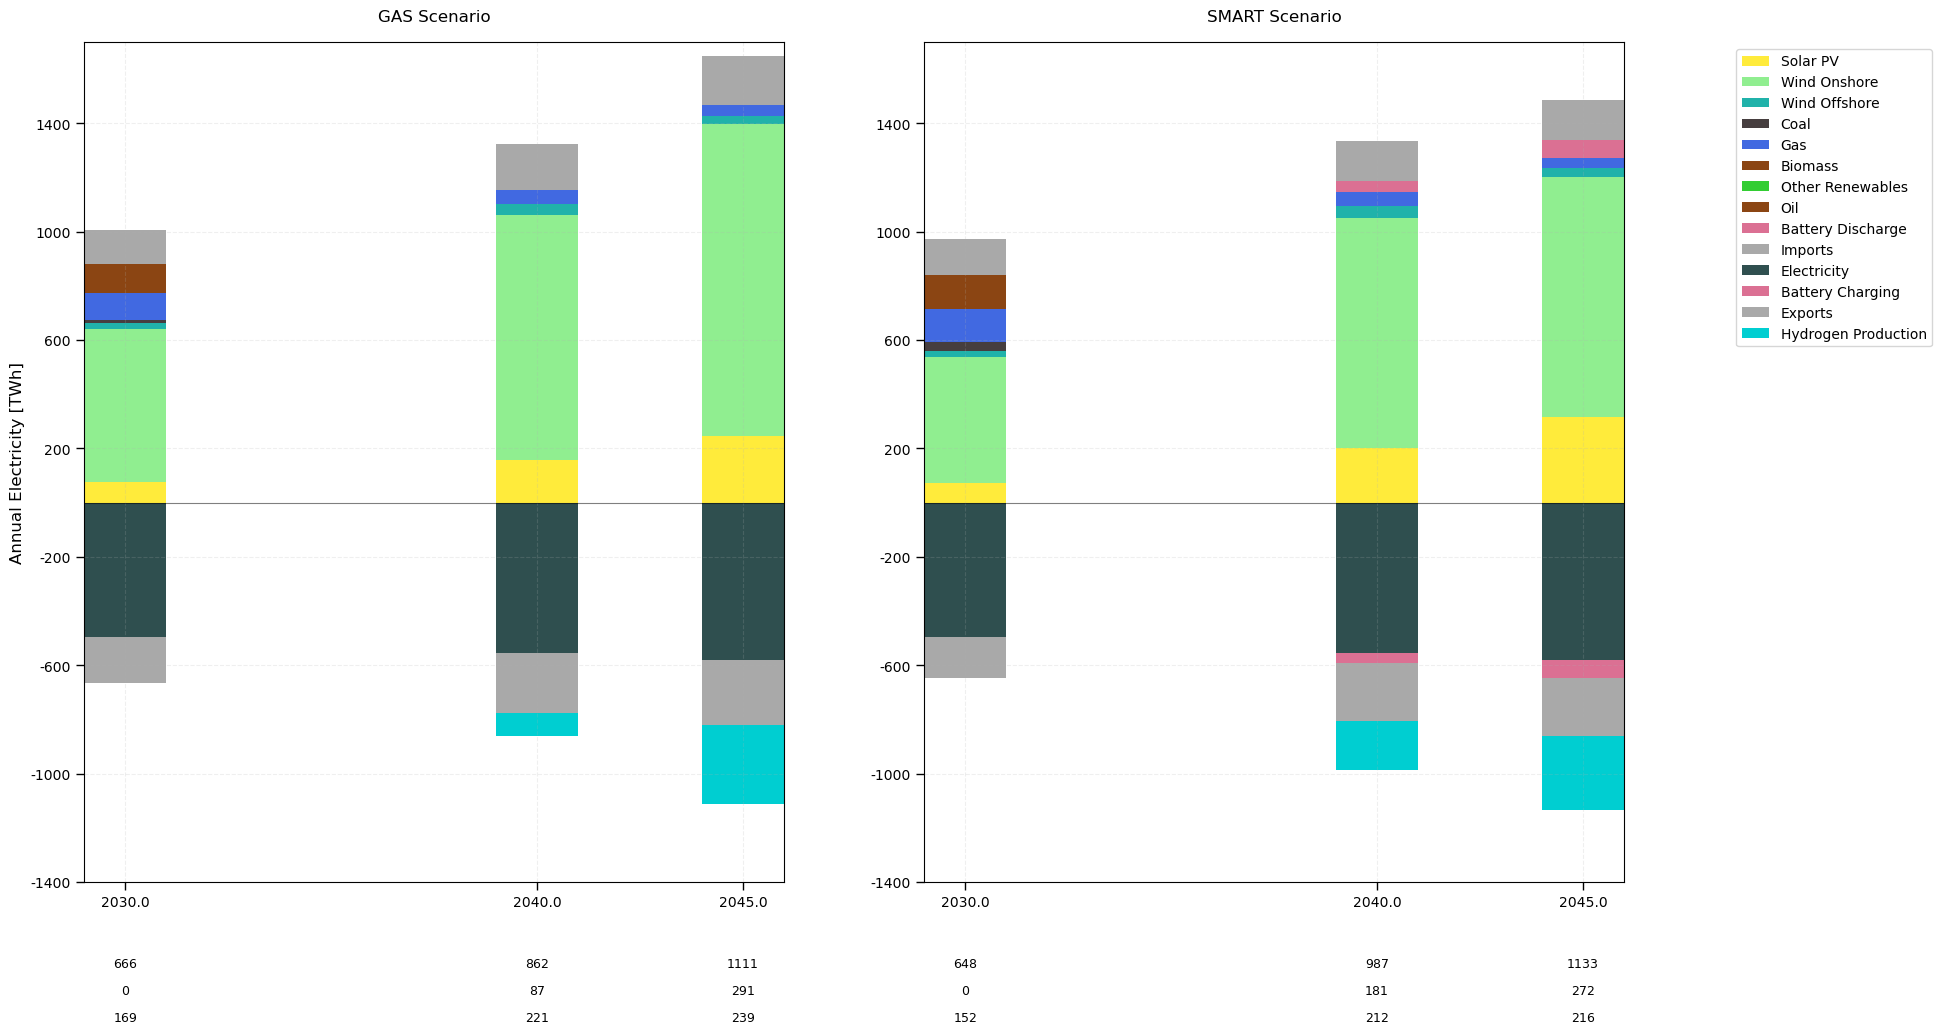

In [1]:
import pypsa
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_electricity_balance(networks, years, scenarios):
    # Initialize dictionaries to store data
    scenario_data = {}
    summaries = {}
    
    # Process data for each scenario
    for scenario in scenarios:
        electricity_gen = pd.DataFrame(index=years)
        electricity_cons = pd.DataFrame(index=years)
        
        for year in years:
            n = networks[scenario][year]
            
            # Get German buses first
            german_buses = n.buses[n.buses.index.str.startswith('DE')].index
            
            # Calculate generation components
            # Get German generators
            german_gens = n.generators[n.generators.bus.isin(german_buses)]
            
            # Solar (including all solar variants)
            solar_gens = german_gens[
                german_gens.carrier.isin(['solar', 'solar rooftop', 'solar-hsat'])
            ].index
            electricity_gen.loc[year, 'Solar PV'] = n.generators_t.p[solar_gens].sum().sum()
            
            # Wind Onshore
            wind_onshore = german_gens[
                german_gens.carrier == 'onwind'
            ].index
            electricity_gen.loc[year, 'Wind Onshore'] = n.generators_t.p[wind_onshore].sum().sum()
            
            # Wind Offshore (including all offshore variants)
            wind_offshore = german_gens[
                german_gens.carrier.isin(['offwind-ac', 'offwind-dc', 'offwind-float'])
            ].index
            electricity_gen.loc[year, 'Wind Offshore'] = n.generators_t.p[wind_offshore].sum().sum()
            
            # Get German links
            german_links = n.links[
                n.links.bus0.isin(german_buses) | 
                n.links.bus1.isin(german_buses)
            ]
            
            # Coal (including all coal variants)
            coal_links = german_links[
                german_links.carrier.isin(['coal', 'lignite'])
            ].index
            electricity_gen.loc[year, 'Coal'] = n.links_t.p0[coal_links].sum().sum()
            
           # Update Gas generation to include urban central CHP
            gas_links = german_links[
                german_links.carrier.isin(['CCGT', 'OCGT', 'urban central gas CHP'])
            ].index
            electricity_gen.loc[year, 'Gas'] = n.links_t.p0[gas_links].sum().sum()
            
            # Add Oil generation
            oil_links = german_links[
                german_links.carrier == 'oil'
            ].index
            if len(oil_links) > 0:
                electricity_gen.loc[year, 'Oil'] = n.links_t.p0[oil_links].sum().sum()
            else:
                electricity_gen.loc[year, 'Oil'] = 0
            
                
            # Biomass (if present)
            biomass_links = german_links[
                german_links.carrier == 'urban central solid biomass CHP'
            ].index
            if len(biomass_links) > 0:
                electricity_gen.loc[year, 'Biomass'] = n.links_t.p0[biomass_links].sum().sum()
            else:
                electricity_gen.loc[year, 'Biomass'] = 0
                
            # Other renewables (like geothermal, if present)
            other_renewable_gens = german_gens[
                german_gens.carrier.isin(['geothermal', 'run_of_river', 'ror'])
            ].index
            if len(other_renewable_gens) > 0:
                electricity_gen.loc[year, 'Other Renewables'] = n.generators_t.p[other_renewable_gens].sum().sum()
            else:
                electricity_gen.loc[year, 'Other Renewables'] = 0
            
            # Calculate imports/exports
            import_flows = 0
            export_flows = 0
            
            # AC lines
            cross_border_lines = n.lines[
                (n.lines.bus0.isin(german_buses) & ~n.lines.bus1.isin(german_buses)) |
                (~n.lines.bus0.isin(german_buses) & n.lines.bus1.isin(german_buses))
            ]
            
            for line in cross_border_lines.index:
                flow = n.lines_t.p0[line]
                if cross_border_lines.loc[line, 'bus0'] in german_buses:
                    export_flows += flow[flow > 0].sum()
                    import_flows -= flow[flow < 0].sum()
                else:
                    import_flows += flow[flow > 0].sum()
                    export_flows -= flow[flow < 0].sum()
            
            electricity_gen.loc[year, 'Imports'] = import_flows
            # Calculate consumption components
             # Calculate consumption components
            # Electricity demand breakdown by sector
            german_loads = n.loads[n.loads.bus.isin(german_buses)]
            
            # Regular electricity loads by sector
            electricity_cons.loc[year, 'Electricity'] = (
                # Regular electricity
                n.loads_t.p[german_loads[german_loads.carrier == 'electricity'].index].sum().sum() +
                # Agriculture electricity
                n.loads_t.p[german_loads[german_loads.carrier == 'agriculture electricity'].index].sum().sum() +
                # Industry electricity
                n.loads_t.p[german_loads[german_loads.carrier == 'industry electricity'].index].sum().sum()
            )
            
           # Battery charging (both regular and home batteries)
            battery_charger_links = german_links[
                german_links.carrier.isin(['battery charger', 'home battery charger'])
            ].index
            if len(battery_charger_links) > 0:
                electricity_cons.loc[year, 'Battery Charging'] = abs(
                    n.links_t.p0[battery_charger_links].sum().sum()
                )
            else:
                electricity_cons.loc[year, 'Battery Charging'] = 0

            # Battery discharging (both regular and home batteries)
            battery_discharger_links = german_links[
                german_links.carrier.isin(['battery discharger', 'home battery discharger'])
            ].index
            if len(battery_discharger_links) > 0:
                electricity_gen.loc[year, 'Battery Discharge'] = abs(
                    n.links_t.p0[battery_discharger_links].sum().sum()
                )
            else:
                electricity_gen.loc[year, 'Battery Discharge'] = 0
            
            # Exports
            electricity_cons.loc[year, 'Exports'] = export_flows
            
            # Hydrogen production
            h2_links = german_links[
                german_links.carrier == 'H2 Electrolysis'
            ].index
            if len(h2_links) > 0:
                electricity_cons.loc[year, 'Hydrogen Production'] = abs(
                    n.links_t.p0[h2_links].sum().sum()
                )
            else:
                electricity_cons.loc[year, 'Hydrogen Production'] = 0
        
        scenario_data[scenario] = {
            'generation': electricity_gen,
            'consumption': electricity_cons
        }
        
        # Calculate summaries
        summaries[scenario] = {
            'total_generation': electricity_gen.sum(axis=1),
            'total_consumption': electricity_cons.sum(axis=1),
            'renewable_share': (
                (electricity_gen['Solar PV'] + 
                 electricity_gen['Wind Onshore'] + 
                 electricity_gen['Wind Offshore'] +
                 electricity_gen['Biomass'] +
                 electricity_gen['Other Renewables']) / 
                electricity_gen.sum(axis=1) * 100
            )
        }
        
    plt.figure(figsize=(20, 12))
    
    # Fixed y-axis limits and parameters
    y_min = -1400
    y_max = 1700
    yticks = np.arange(-1400, 1701, 400)
    # Exact colors from the example
    generation_colors = {
        'Solar PV': '#ffeb3b',        # Bright yellow
        'Wind Onshore': '#90ee90',    # Light green
        'Wind Offshore': '#20b2aa',   # Teal
        'Coal': '#463e3f',           # Dark gray
        'Gas': '#4169e1',            # Royal blue
        'Biomass': '#8b4513',        # Saddle brown
        'Other Renewables': '#32cd32', # Lime green
        'Oil': '#8B4513',            # Brown
        'Battery Discharge': '#db7093', # Pink
        'Imports': '#a9a9a9'         # Gray
     }

    consumption_colors = {
        'Electricity': '#2f4f4f',     # Dark slate gray
        'Battery Charging': '#db7093', # Pink
        'Exports': '#a9a9a9',         # Gray
        'Hydrogen Production': '#00ced1' # Turquoise
     }
    
    for idx, scenario in enumerate(scenarios):
        ax = plt.subplot(1, 2, idx+1)
        
        gen_data = scenario_data[scenario]['generation'].div(1e6)
        cons_data = scenario_data[scenario]['consumption'].div(1e6)
        
        # Plot generation (positive values)
        bottom_pos = pd.Series(0, index=years)
        for source, color in generation_colors.items():
            if source in gen_data.columns:
                values = gen_data[source]
                bars = ax.bar(years, values, bottom=bottom_pos, 
                            label=source, color=color, width=2)
                
                # Add value labels
                for year in years:
                    if values[year] > 2000:
                        ax.text(year, bottom_pos[year] + values[year]/2, 
                               f'{values[year]:.0f}',
                               ha='center', va='center',
                               fontsize=9,
                               color='black',
                               bbox=dict(facecolor='white', alpha=0.7, 
                                       edgecolor='none', pad=1))
                bottom_pos += values
        
        # Plot consumption (negative values)
        bottom_neg = pd.Series(0, index=years)
        for category, color in consumption_colors.items():
            if category in cons_data.columns:
                values = -cons_data[category]
                bars = ax.bar(years, values, bottom=bottom_neg, 
                            label=category, color=color, width=2)
                
                # Only add visible labels for Electricity consumption
                if category == 'Electricity':
                    for year in years:
                        if abs(values[year]) > 2000:
                            ax.text(year, bottom_neg[year] + values[year]/2, 
                                   f'{abs(cons_data.loc[year, category]):.0f}',
                                   ha='center', va='center',
                                   fontsize=9,
                                   color='black',
                                   bbox=dict(facecolor='white', alpha=0.7, 
                                           edgecolor='none', pad=1))
                bottom_neg += values
                # Add total generation and consumption values at bottom
        for year in years:
            # Position for bottom values adjusted based on actual data
            total_label_pos = -1700  # Total consumption
            h2_label_pos = -1800    # Hydrogen production
            export_label_pos = -1900  # Exports
            
            # Total consumption (bottom number)
            total_cons = cons_data.loc[year].sum()
            ax.text(year, total_label_pos, f'{abs(total_cons):.0f}',
                   ha='center', va='center', fontsize=9,
                   bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
            
            # Add Hydrogen Production value if present
            if 'Hydrogen Production' in cons_data and cons_data.loc[year, 'Hydrogen Production'] > 0:
                h2_val = cons_data.loc[year, 'Hydrogen Production']
                if h2_val > 0:
                    ax.text(year, h2_label_pos, f'{h2_val:.0f}',
                           ha='center', va='center', fontsize=9,
                           bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
            
            # Add Exports value
            if 'Exports' in cons_data:
                export_val = cons_data.loc[year, 'Exports']
                ax.text(year, export_label_pos, f'{export_val:.0f}',
                       ha='center', va='center', fontsize=9,
                       bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
        
        # Customize plot
        ax.set_title(f'{scenario.upper()} Scenario', pad=15, fontsize=12)
        if idx == 0:
            ax.set_ylabel('Annual Electricity [TWh]', fontsize=12)
        
        # Set axes with new limits and make sure ticks are visible
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(yticks)
        ax.set_yticklabels([str(int(y)) for y in yticks], fontsize=10)
        
        # X-axis settings with visible ticks
        ax.set_xlim(2029, 2046)
        ax.set_xticks(years)
        ax.set_xticklabels([f'{year:.1f}' for year in years], fontsize=10)
        
        # Make ticks more visible
        ax.tick_params(axis='both', which='major', length=6, width=1)
        
        # Grid and zero line
        ax.grid(True, alpha=0.2, linestyle='--')
        ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
        # Legend only for the right subplot
        if idx == len(scenarios)-1:
            legend = ax.legend(bbox_to_anchor=(1.15, 1),
                             loc='upper left',
                             fontsize=10)
            for item in legend.get_texts():
                item.set_ha('left')
    
    # Adjusted subplot parameters
    plt.subplots_adjust(left=0.08,
                       right=0.85,
                       bottom=0.2,
                       top=0.9,
                       wspace=0.2)
    
    plt.savefig('electricity_balance.png', dpi=300, bbox_inches='tight', pad_inches=0.2)
    plt.savefig('electricity_balance.pdf', bbox_inches='tight', pad_inches=0.2)
    
    return scenario_data, summaries

# Main execution
network_dir = "/home/mohsen/PycharmProjects/PyPSA-Eur/pypsa-eur-flexibility/results/scenario/gas-smart-myopic/networks"
output_dir = "/home/mohsen/PycharmProjects/PyPSA-Eur/pypsa-eur-flexibility/results/scenario/gas-smart-myopic/germany_statistics_output"
years = [2030, 2040, 2045]
scenarios = ['gas', 'smart']

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Store networks directly
networks = {scenario: {} for scenario in scenarios}

for scenario in scenarios:
    print(f"\nProcessing {scenario} scenario...")
    for year in years:
        print(f"Processing year {year}...")
        network_file = f"{scenario}_s_27_CLL-CCL-1H_1H_{year}.nc"
        network_path = os.path.join(network_dir, network_file)
        
        try:
            networks[scenario][year] = pypsa.Network(network_path)
        except Exception as e:
            print(f"Error processing {scenario} scenario, year {year}: {str(e)}")
            continue

# Call the analysis function
scenario_data, summaries = analyze_electricity_balance(networks, years, scenarios)

# Print additional information about the results
for scenario in scenarios:
    print(f"\nDetailed Generation Mix - {scenario.upper()} scenario (TWh):")
    print(scenario_data[scenario]['generation'].div(1e6).round(2))
    
    print(f"\nDetailed Consumption Mix - {scenario.upper()} scenario (TWh):")
    print(scenario_data[scenario]['consumption'].div(1e6).round(2))
    
    # Calculate trade balance
    trade_balance = pd.DataFrame(index=years)
    trade_balance['Imports'] = scenario_data[scenario]['generation']['Imports'].div(1e6)
    trade_balance['Exports'] = scenario_data[scenario]['consumption']['Exports'].div(1e6)
    trade_balance['Net Trade'] = trade_balance['Imports'] - trade_balance['Exports']
    
    print(f"\nElectricity Trade Balance - {scenario.upper()} scenario (TWh):")
    print(trade_balance.round(2))
    
    print(f"\nSummary Statistics - {scenario.upper()} scenario:")
    print(f"Total Generation (TWh):\n{summaries[scenario]['total_generation'].div(1e6).round(2)}")
    print(f"Total Consumption (TWh):\n{summaries[scenario]['total_consumption'].div(1e6).round(2)}")
    print(f"Renewable Share (%):\n{summaries[scenario]['renewable_share'].round(2)}")


Processing gas scenario...
Processing year 2030...


INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Processing year 2040...


INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Processing year 2045...


...

Processing year 2040...


INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


Processing year 2045...


INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



GAS SCENARIO SUMMARY

GENERATION MIX (TWh):
------------------------------
      Solar PV  Wind Onshore  Wind Offshore   Coal    Gas   Oil  Biomass  \
2030     75.14        567.36          20.62  10.26  99.89  0.01   109.09   
2040    157.91        904.61          40.09   0.00  51.04  0.00     1.74   
2045    245.14       1153.43          28.42   0.00  40.64  0.00     0.00   

      Other Renewables  Imports  Battery Discharge  
2030               0.0   124.45                0.0  
2040               0.0   168.74                0.0  
2045               0.0   181.72                0.0  

CONSUMPTION MIX (TWh):
------------------------------
      Electricity  Battery Charging  Exports  Hydrogen Production
2030       496.13               0.0   169.38                 0.00
2040       554.12               0.0   221.38                86.98
2045       581.30               0.0   238.56               290.96

TRADE BALANCE (TWh):
------------------------------
      Imports  Exports  Net Trade
2

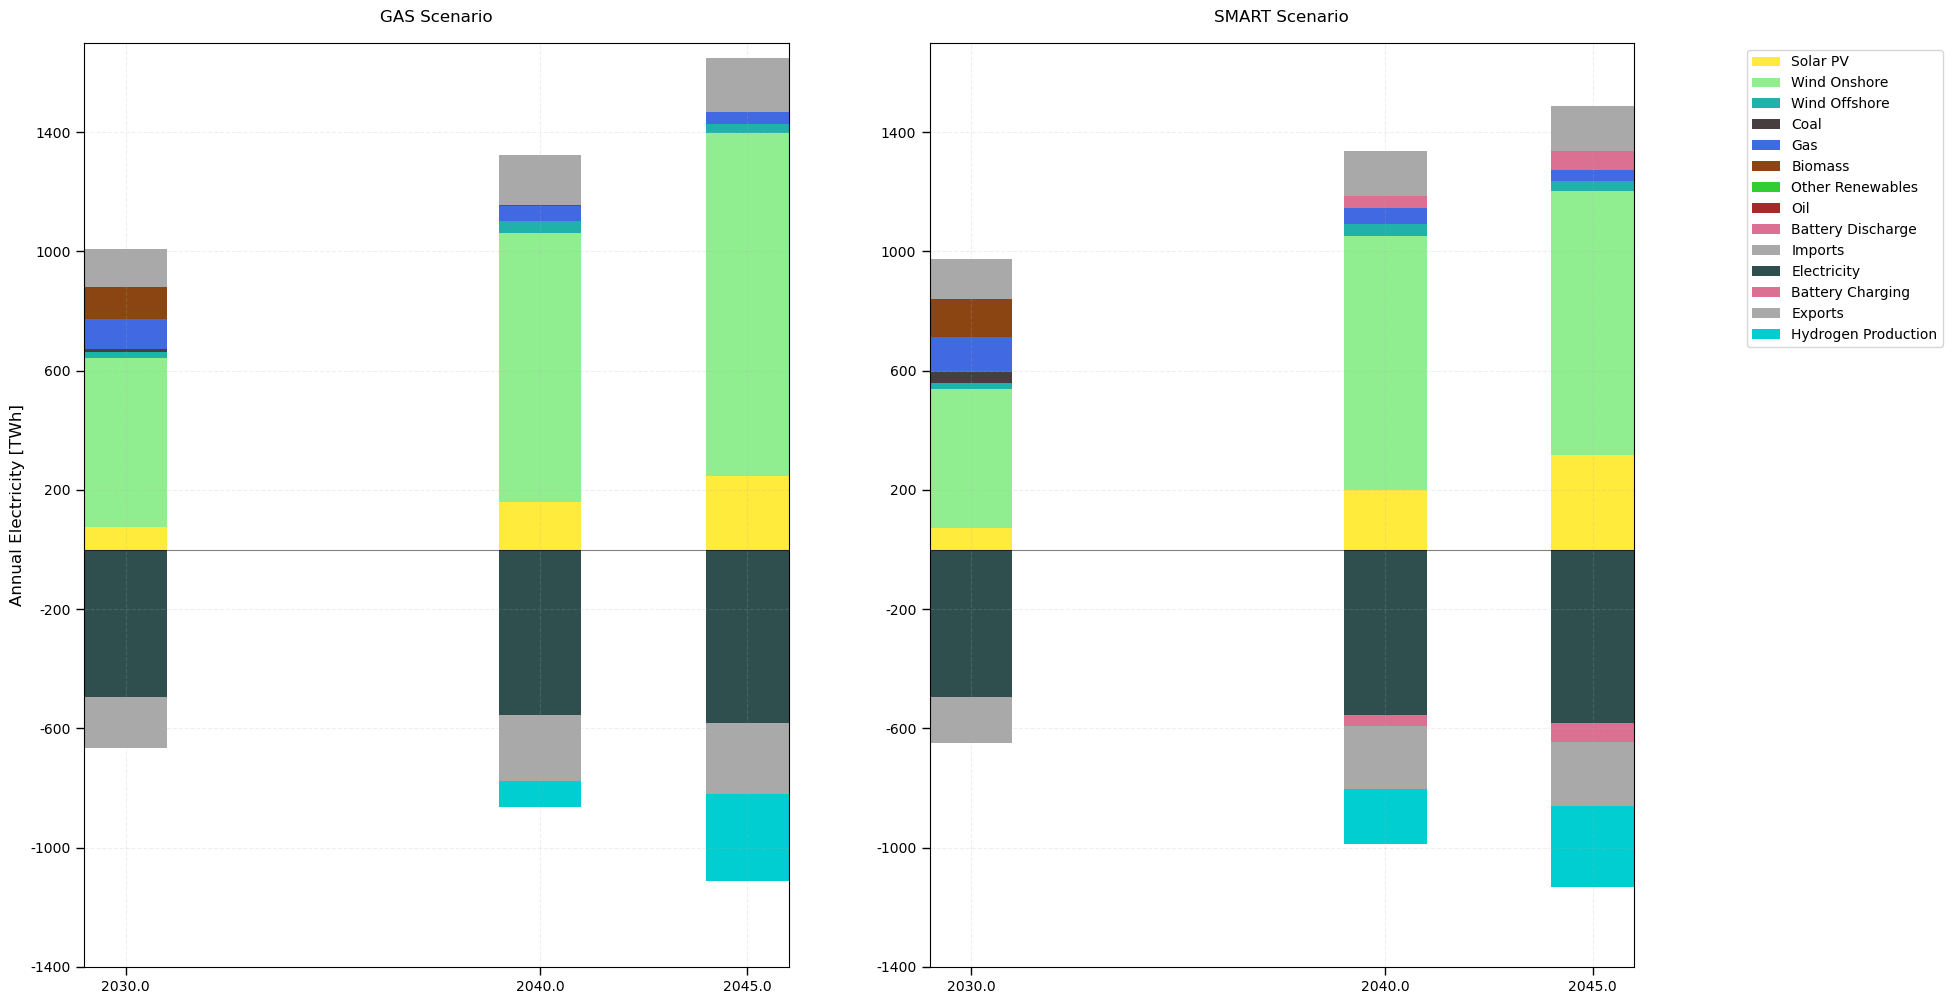

In [1]:
import pypsa
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_electricity_balance(networks, years, scenarios):
    # Initialize dictionaries to store data
    scenario_data = {}
    summaries = {}
    
    # Process data for each scenario
    for scenario in scenarios:
        electricity_gen = pd.DataFrame(index=years)
        electricity_cons = pd.DataFrame(index=years)
        
        for year in years:
            n = networks[scenario][year]
            
            # Get German buses first
            german_buses = n.buses[n.buses.index.str.startswith('DE')].index
            
            # Calculate generation components
            # Get German generators
            german_gens = n.generators[n.generators.bus.isin(german_buses)]
            
            # Solar (including all solar variants)
            solar_gens = german_gens[
                german_gens.carrier.isin(['solar', 'solar rooftop', 'solar-hsat'])
            ].index
            electricity_gen.loc[year, 'Solar PV'] = n.generators_t.p[solar_gens].sum().sum()
            
            # Wind Onshore
            wind_onshore = german_gens[
                german_gens.carrier == 'onwind'
            ].index
            electricity_gen.loc[year, 'Wind Onshore'] = n.generators_t.p[wind_onshore].sum().sum()
            
            # Wind Offshore (including all offshore variants)
            wind_offshore = german_gens[
                german_gens.carrier.isin(['offwind-ac', 'offwind-dc', 'offwind-float'])
            ].index
            electricity_gen.loc[year, 'Wind Offshore'] = n.generators_t.p[wind_offshore].sum().sum()
            
            # Get German links
            german_links = n.links[
                n.links.bus0.isin(german_buses) | 
                n.links.bus1.isin(german_buses)
            ]
            
            # Coal (including all coal variants)
            coal_links = german_links[
                german_links.carrier.isin(['coal', 'lignite'])
            ].index
            electricity_gen.loc[year, 'Coal'] = n.links_t.p0[coal_links].sum().sum()
            
           # Update Gas generation to include urban central CHP
            gas_links = german_links[
                german_links.carrier.isin(['CCGT', 'OCGT', 'urban central gas CHP'])
            ].index
            electricity_gen.loc[year, 'Gas'] = n.links_t.p0[gas_links].sum().sum()
            
            # Add Oil generation
            oil_links = german_links[
                german_links.carrier == 'oil'
            ].index
            if len(oil_links) > 0:
                electricity_gen.loc[year, 'Oil'] = n.links_t.p0[oil_links].sum().sum()
            else:
                electricity_gen.loc[year, 'Oil'] = 0
            
                
            # Biomass (if present)
            biomass_links = german_links[
                german_links.carrier == 'urban central solid biomass CHP'
            ].index
            if len(biomass_links) > 0:
                electricity_gen.loc[year, 'Biomass'] = n.links_t.p0[biomass_links].sum().sum()
            else:
                electricity_gen.loc[year, 'Biomass'] = 0
                
            # Other renewables (like geothermal, if present)
            other_renewable_gens = german_gens[
                german_gens.carrier.isin(['geothermal', 'run_of_river', 'ror'])
            ].index
            if len(other_renewable_gens) > 0:
                electricity_gen.loc[year, 'Other Renewables'] = n.generators_t.p[other_renewable_gens].sum().sum()
            else:
                electricity_gen.loc[year, 'Other Renewables'] = 0
            
            # Calculate imports/exports
            import_flows = 0
            export_flows = 0
            
            # AC lines
            cross_border_lines = n.lines[
                (n.lines.bus0.isin(german_buses) & ~n.lines.bus1.isin(german_buses)) |
                (~n.lines.bus0.isin(german_buses) & n.lines.bus1.isin(german_buses))
            ]
            
            for line in cross_border_lines.index:
                flow = n.lines_t.p0[line]
                if cross_border_lines.loc[line, 'bus0'] in german_buses:
                    export_flows += flow[flow > 0].sum()
                    import_flows -= flow[flow < 0].sum()
                else:
                    import_flows += flow[flow > 0].sum()
                    export_flows -= flow[flow < 0].sum()
            
            electricity_gen.loc[year, 'Imports'] = import_flows
            # Calculate consumption components
             # Calculate consumption components
            # Electricity demand breakdown by sector
            german_loads = n.loads[n.loads.bus.isin(german_buses)]
            
            # Regular electricity loads by sector
            electricity_cons.loc[year, 'Electricity'] = (
                # Regular electricity
                n.loads_t.p[german_loads[german_loads.carrier == 'electricity'].index].sum().sum() +
                # Agriculture electricity
                n.loads_t.p[german_loads[german_loads.carrier == 'agriculture electricity'].index].sum().sum() +
                # Industry electricity
                n.loads_t.p[german_loads[german_loads.carrier == 'industry electricity'].index].sum().sum()
            )
            
           # Battery charging (both regular and home batteries)
            battery_charger_links = german_links[
                german_links.carrier.isin(['battery charger', 'home battery charger'])
            ].index
            if len(battery_charger_links) > 0:
                electricity_cons.loc[year, 'Battery Charging'] = abs(
                    n.links_t.p0[battery_charger_links].sum().sum()
                )
            else:
                electricity_cons.loc[year, 'Battery Charging'] = 0

            # Battery discharging (both regular and home batteries)
            battery_discharger_links = german_links[
                german_links.carrier.isin(['battery discharger', 'home battery discharger'])
            ].index
            if len(battery_discharger_links) > 0:
                electricity_gen.loc[year, 'Battery Discharge'] = abs(
                    n.links_t.p0[battery_discharger_links].sum().sum()
                )
            else:
                electricity_gen.loc[year, 'Battery Discharge'] = 0
            
            # Exports
            electricity_cons.loc[year, 'Exports'] = export_flows
            
            # Hydrogen production
            h2_links = german_links[
                german_links.carrier == 'H2 Electrolysis'
            ].index
            if len(h2_links) > 0:
                electricity_cons.loc[year, 'Hydrogen Production'] = abs(
                    n.links_t.p0[h2_links].sum().sum()
                )
            else:
                electricity_cons.loc[year, 'Hydrogen Production'] = 0
        
        scenario_data[scenario] = {
            'generation': electricity_gen,
            'consumption': electricity_cons
        }
        
        # Calculate summaries
        summaries[scenario] = {
            'total_generation': electricity_gen.sum(axis=1),
            'total_consumption': electricity_cons.sum(axis=1),
            'renewable_share': (
                (electricity_gen['Solar PV'] + 
                 electricity_gen['Wind Onshore'] + 
                 electricity_gen['Wind Offshore'] +
                 electricity_gen['Biomass'] +
                 electricity_gen['Other Renewables']) / 
                (electricity_gen['Solar PV'] + 
                 electricity_gen['Wind Onshore'] + 
                 electricity_gen['Wind Offshore'] +
                 electricity_gen['Biomass'] +
                 electricity_gen['Other Renewables'] +
                 electricity_gen['Coal'] +
                 electricity_gen['Gas'] +
                 electricity_gen['Oil']) * 100
            )
        }
        
    plt.figure(figsize=(20, 12))
    
    # Fixed y-axis limits and parameters
    y_min = -1400
    y_max = 1700
    yticks = np.arange(-1400, 1701, 400)
    # Exact colors from the example
    generation_colors = {
        'Solar PV': '#ffeb3b',        # Bright yellow
        'Wind Onshore': '#90ee90',    # Light green
        'Wind Offshore': '#20b2aa',   # Teal
        'Coal': '#463e3f',           # Dark gray
        'Gas': '#4169e1',            # Royal blue
        'Biomass': '#8b4513',        # Saddle brown
        'Other Renewables': '#32cd32', # Lime green
        'Oil': '#A52A2A',            # Different brown for oil
        'Battery Discharge': '#db7093', # Pink
        'Imports': '#a9a9a9'         # Gray
    }

    consumption_colors = {
        'Electricity': '#2f4f4f',     # Dark slate gray
        'Battery Charging': '#db7093', # Pink
        'Exports': '#a9a9a9',         # Gray
        'Hydrogen Production': '#00ced1' # Turquoise
     }
    
    for idx, scenario in enumerate(scenarios):
        ax = plt.subplot(1, 2, idx+1)
        
        gen_data = scenario_data[scenario]['generation'].div(1e6)
        cons_data = scenario_data[scenario]['consumption'].div(1e6)
        
        # Plot generation (positive values)
        bottom_pos = pd.Series(0, index=years)
        for source, color in generation_colors.items():
            if source in gen_data.columns:
                values = gen_data[source]
                bars = ax.bar(years, values, bottom=bottom_pos, 
                            label=source, color=color, width=2)
                bottom_pos += values
        
        # Plot consumption (negative values)
        bottom_neg = pd.Series(0, index=years)
        for category, color in consumption_colors.items():
            if category in cons_data.columns:
                values = -cons_data[category]
                bars = ax.bar(years, values, bottom=bottom_neg, 
                            label=category, color=color, width=2)
                bottom_neg += values
        
        # Customize plot
        ax.set_title(f'{scenario.upper()} Scenario', pad=15, fontsize=12)
        if idx == 0:
            ax.set_ylabel('Annual Electricity [TWh]', fontsize=12)
        
        # Set axes with new limits and make sure ticks are visible
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(yticks)
        ax.set_yticklabels([str(int(y)) for y in yticks], fontsize=10)
        
        # X-axis settings with visible ticks
        ax.set_xlim(2029, 2046)
        ax.set_xticks(years)
        ax.set_xticklabels([f'{year:.1f}' for year in years], fontsize=10)
        
        # Make ticks more visible
        ax.tick_params(axis='both', which='major', length=6, width=1)
        
        # Grid and zero line
        ax.grid(True, alpha=0.2, linestyle='--')
        ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
        
        # Legend only for the right subplot
        if idx == len(scenarios)-1:
            legend = ax.legend(bbox_to_anchor=(1.15, 1),
                             loc='upper left',
                             fontsize=10)
            for item in legend.get_texts():
                item.set_ha('left')
    
    plt.savefig('electricity_balance.png', dpi=300, bbox_inches='tight', pad_inches=0.2)
    plt.savefig('electricity_balance.pdf', bbox_inches='tight', pad_inches=0.2)
    
    return scenario_data, summaries

# Main execution
network_dir = "/home/mohsen/PycharmProjects/PyPSA-Eur/pypsa-eur-flexibility/results/scenario/gas-smart-myopic/networks"
output_dir = "/home/mohsen/PycharmProjects/PyPSA-Eur/pypsa-eur-flexibility/results/scenario/gas-smart-myopic/germany_statistics_output"
years = [2030, 2040, 2045]
scenarios = ['gas', 'smart']

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Store networks directly
networks = {scenario: {} for scenario in scenarios}

for scenario in scenarios:
    print(f"\nProcessing {scenario} scenario...")
    for year in years:
        print(f"Processing year {year}...")
        network_file = f"{scenario}_s_27_CLL-CCL-1H_1H_{year}.nc"
        network_path = os.path.join(network_dir, network_file)
        
        try:
            networks[scenario][year] = pypsa.Network(network_path)
        except Exception as e:
            print(f"Error processing {scenario} scenario, year {year}: {str(e)}")
            continue

# Call the analysis function
scenario_data, summaries = analyze_electricity_balance(networks, years, scenarios)

# Replace the print statements at the end with this:
# Create summary tables
for scenario in scenarios:
    print(f"\n{'='*50}")
    print(f"{scenario.upper()} SCENARIO SUMMARY")
    print(f"{'='*50}")
    
    # Generation Mix Table
    gen_mix = scenario_data[scenario]['generation'].div(1e6).round(2)
    print("\nGENERATION MIX (TWh):")
    print("-"*30)
    print(gen_mix)
    
    # Consumption Mix Table
    cons_mix = scenario_data[scenario]['consumption'].div(1e6).round(2)
    print("\nCONSUMPTION MIX (TWh):")
    print("-"*30)
    print(cons_mix)
    
    # Trade Balance Table
    trade_balance = pd.DataFrame(index=years)
    trade_balance['Imports'] = scenario_data[scenario]['generation']['Imports'].div(1e6)
    trade_balance['Exports'] = scenario_data[scenario]['consumption']['Exports'].div(1e6)
    trade_balance['Net Trade'] = trade_balance['Imports'] - trade_balance['Exports']
    print("\nTRADE BALANCE (TWh):")
    print("-"*30)
    print(trade_balance.round(2))
    
    # Key Metrics Table
    print("\nKEY METRICS:")
    print("-"*30)
    metrics = pd.DataFrame(index=years)
    metrics['Total Generation (TWh)'] = summaries[scenario]['total_generation'].div(1e6).round(2)
    metrics['Total Consumption (TWh)'] = summaries[scenario]['total_consumption'].div(1e6).round(2)
    metrics['Renewable Share (%)'] = summaries[scenario]['renewable_share'].round(2)
    print(metrics)
    
    print(f"\n{'='*50}\n")


Processing gas scenario, year 2030


INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Debugging generators and links:
All link carriers: ['DC' 'oil refining' 'co2 sequestered' 'OCGT' 'H2 Electrolysis'
 'H2 Fuel Cell' 'H2 pipeline' 'Sabatier' 'SMR CC' 'SMR' 'BEV charger'
 'land transport oil' 'urban central resistive heater'
 'urban central gas boiler' 'urban central CHP' 'urban central CHP CC'
 'unsustainable bioliquids' 'biogas to gas' 'solid biomass for industry'
 'solid biomass for industry CC' 'gas for industry' 'gas for industry CC'
 'industry methanol' 'methanolisation' 'shipping methanol' 'shipping oil'
 'Fischer-Tropsch' 'naphtha for industry' 'kerosene for aviation'
 'process emissions' 'process emissions CC' 'coal for industry'
 'agriculture machinery oil' 'DAC' 'electricity distribution grid' 'CCGT'
 'lignite' 'coal' 'nuclear' 'oil' 'urban central solid biomass CHP'
 'rural biomass boiler' 'rural gas boiler' 'rural ground heat pump'
 'rural oil boiler' 'rural resistive heater'
 'urban decentral air heat pump' 'urban decentral biomass boiler'
 'urban decentra

INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Debugging generators and links:
All link carriers: ['DC' 'oil refining' 'co2 sequestered' 'OCGT' 'H2 Electrolysis'
 'H2 Fuel Cell' 'H2 pipeline' 'Sabatier' 'SMR CC' 'SMR' 'BEV charger'
 'land transport oil' 'urban central resistive heater'
 'urban central gas boiler' 'urban central CHP' 'urban central CHP CC'
 'biogas to gas' 'solid biomass for industry'
 'solid biomass for industry CC' 'gas for industry' 'gas for industry CC'
 'industry methanol' 'methanolisation' 'shipping methanol' 'shipping oil'
 'Fischer-Tropsch' 'naphtha for industry' 'kerosene for aviation'
 'process emissions' 'process emissions CC' 'coal for industry'
 'agriculture machinery oil' 'DAC' 'electricity distribution grid'
 'rural biomass boiler' 'rural gas boiler' 'rural resistive heater'
 'urban decentral biomass boiler' 'urban decentral gas boiler'
 'urban decentral resistive heater' 'CCGT' 'lignite' 'nuclear' 'oil'
 'coal' 'urban central solid biomass CHP']

Calculating demand for loads:
electricity: 17744.24 t

...


Debugging generators and links:
All link carriers: ['DC' 'oil refining' 'co2 sequestered' 'OCGT' 'H2 Electrolysis'
 'H2 Fuel Cell' 'H2 pipeline' 'battery charger' 'battery discharger'
 'Sabatier' 'SMR CC' 'SMR' 'BEV charger' 'V2G' 'land transport oil'
 'urban central air heat pump' 'urban central water tanks charger'
 'urban central water tanks discharger' 'urban central resistive heater'
 'urban central gas boiler' 'urban central CHP' 'urban central CHP CC'
 'unsustainable bioliquids' 'biogas to gas' 'solid biomass for industry'
 'solid biomass for industry CC' 'gas for industry' 'gas for industry CC'
 'industry methanol' 'methanolisation' 'shipping methanol' 'shipping oil'
 'Fischer-Tropsch' 'naphtha for industry' 'kerosene for aviation'
 'process emissions' 'process emissions CC' 'coal for industry'
 'agriculture machinery oil' 'DAC' 'electricity distribution grid'
 'home battery charger' 'home battery discharger' 'CCGT' 'lignite' 'coal'
 'nuclear' 'oil' 'urban central solid biomas

INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Debugging generators and links:
All link carriers: ['DC' 'oil refining' 'co2 sequestered' 'OCGT' 'H2 Electrolysis'
 'H2 Fuel Cell' 'H2 pipeline' 'battery charger' 'battery discharger'
 'Sabatier' 'SMR CC' 'SMR' 'BEV charger' 'V2G' 'land transport oil'
 'urban central air heat pump' 'urban central water tanks charger'
 'urban central water tanks discharger' 'urban central resistive heater'
 'urban central gas boiler' 'urban central CHP' 'urban central CHP CC'
 'biogas to gas' 'solid biomass for industry'
 'solid biomass for industry CC' 'gas for industry' 'gas for industry CC'
 'industry methanol' 'methanolisation' 'shipping methanol' 'shipping oil'
 'Fischer-Tropsch' 'naphtha for industry' 'kerosene for aviation'
 'process emissions' 'process emissions CC' 'coal for industry'
 'agriculture machinery oil' 'DAC' 'electricity distribution grid'
 'home battery charger' 'home battery discharger' 'rural air heat pump'
 'rural biomass boiler' 'rural gas boiler' 'rural ground heat pump'
 'rur

INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Debugging generators and links:
All link carriers: ['DC' 'oil refining' 'co2 sequestered' 'OCGT' 'H2 Electrolysis'
 'H2 Fuel Cell' 'H2 pipeline' 'battery charger' 'battery discharger'
 'Sabatier' 'SMR CC' 'SMR' 'BEV charger' 'V2G' 'land transport oil'
 'urban central air heat pump' 'urban central water tanks charger'
 'urban central water tanks discharger' 'urban central resistive heater'
 'urban central gas boiler' 'urban central CHP' 'urban central CHP CC'
 'biogas to gas' 'solid biomass for industry'
 'solid biomass for industry CC' 'gas for industry' 'gas for industry CC'
 'industry methanol' 'methanolisation' 'shipping methanol' 'shipping oil'
 'Fischer-Tropsch' 'naphtha for industry' 'kerosene for aviation'
 'process emissions' 'process emissions CC' 'coal for industry'
 'agriculture machinery oil' 'DAC' 'electricity distribution grid'
 'home battery charger' 'home battery discharger' 'rural air heat pump'
 'rural biomass boiler' 'rural gas boiler' 'rural ground heat pump'
 'rur

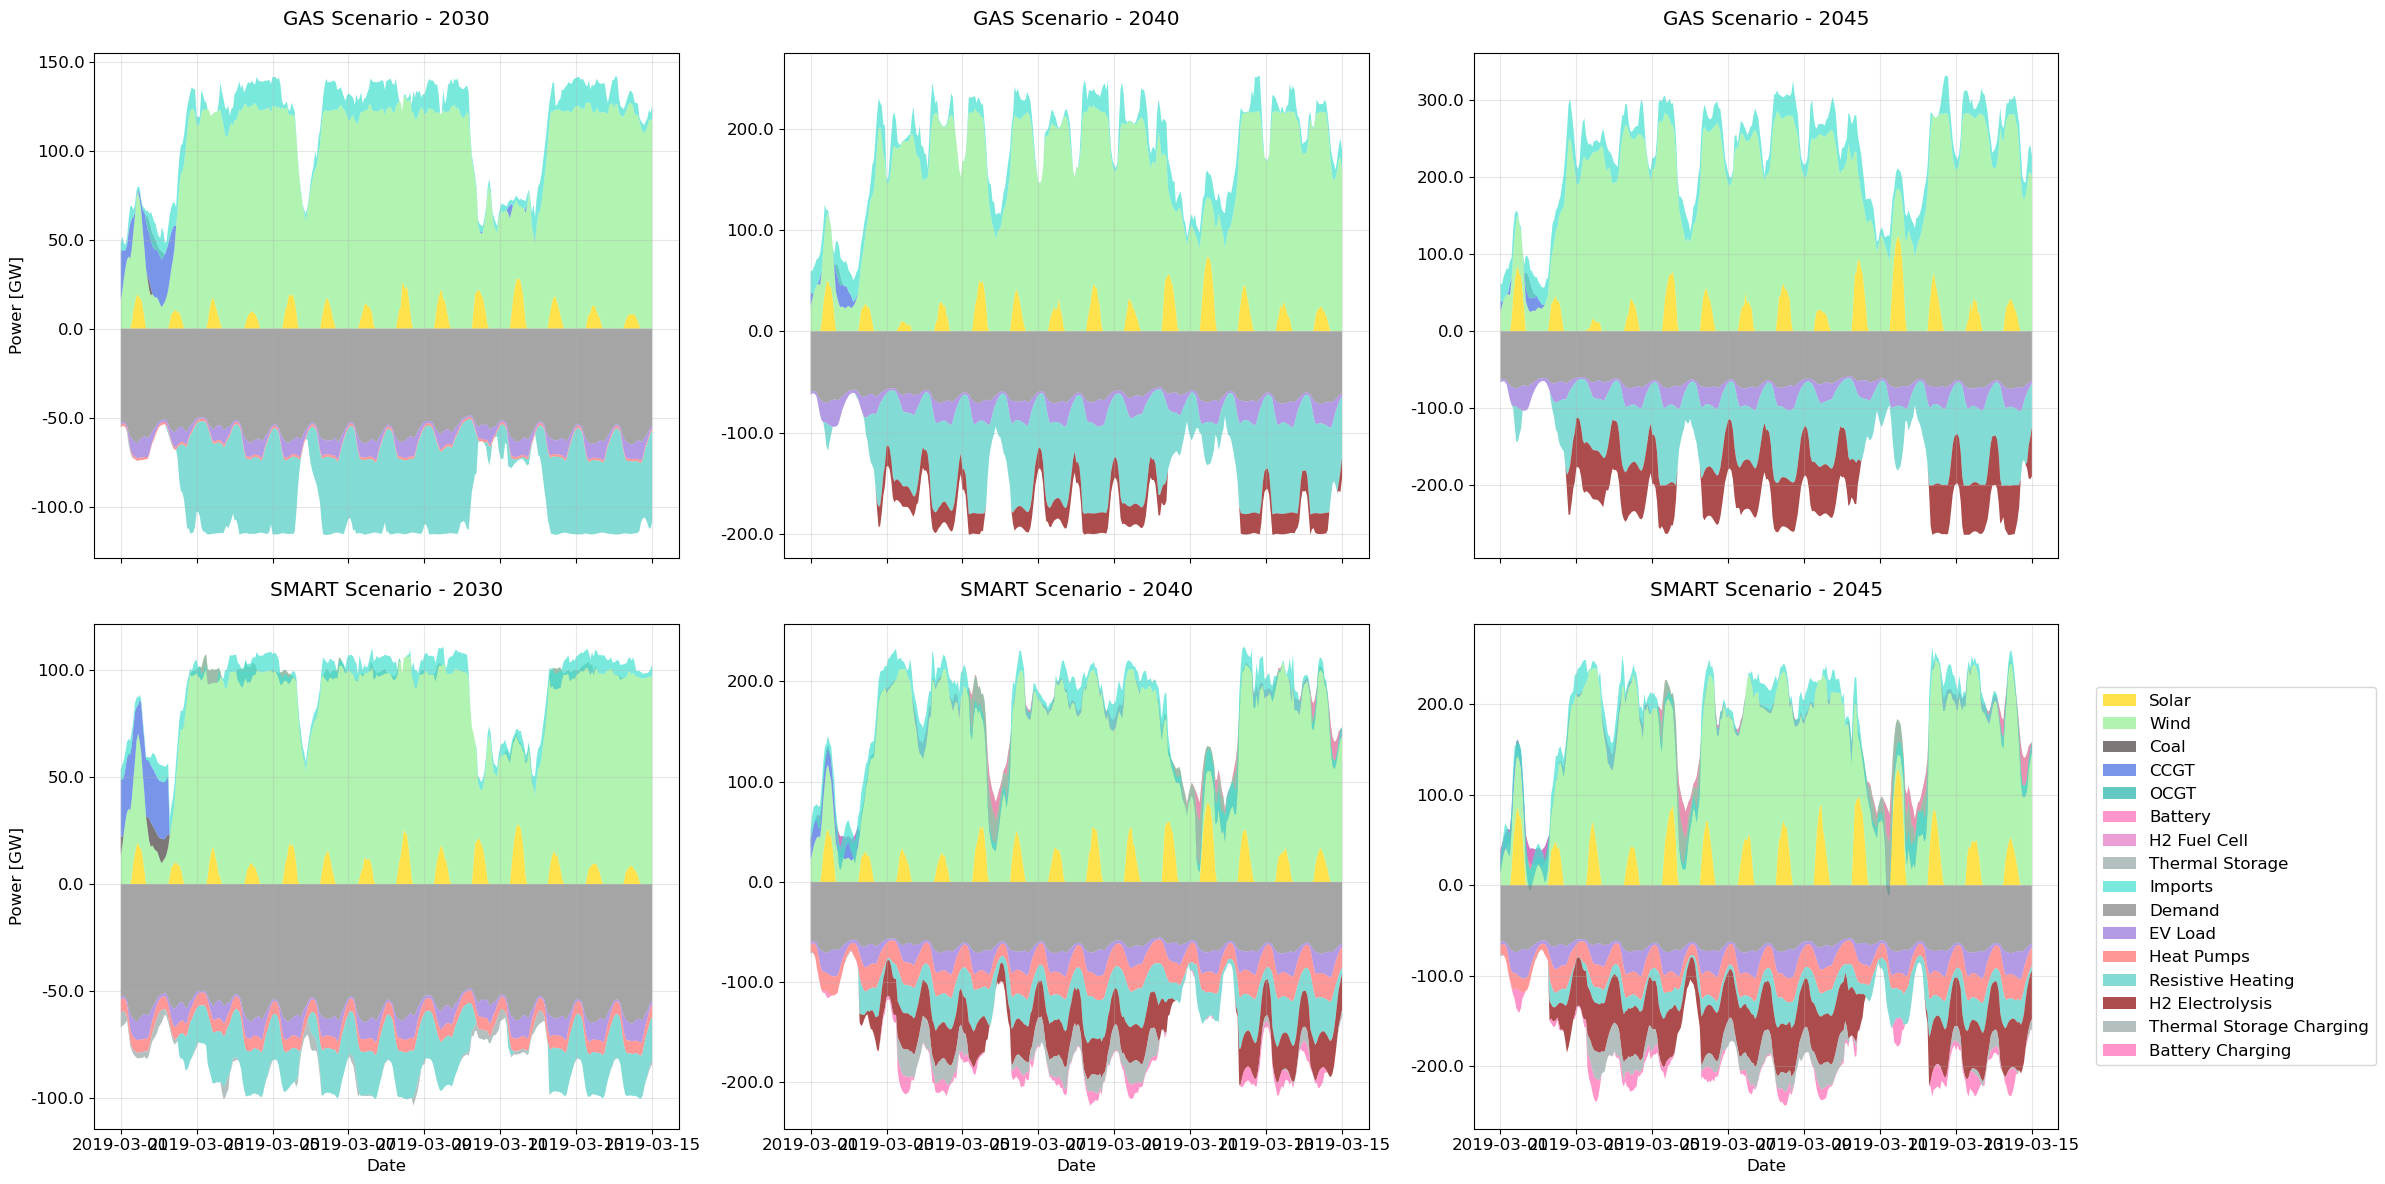

Completed timeseries plotting

Processing gas scenario, year 2030


INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Processing gas scenario, year 2040


INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Processing gas scenario, year 2045


...

INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Processing smart scenario, year 2040


INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Processing smart scenario, year 2045


INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


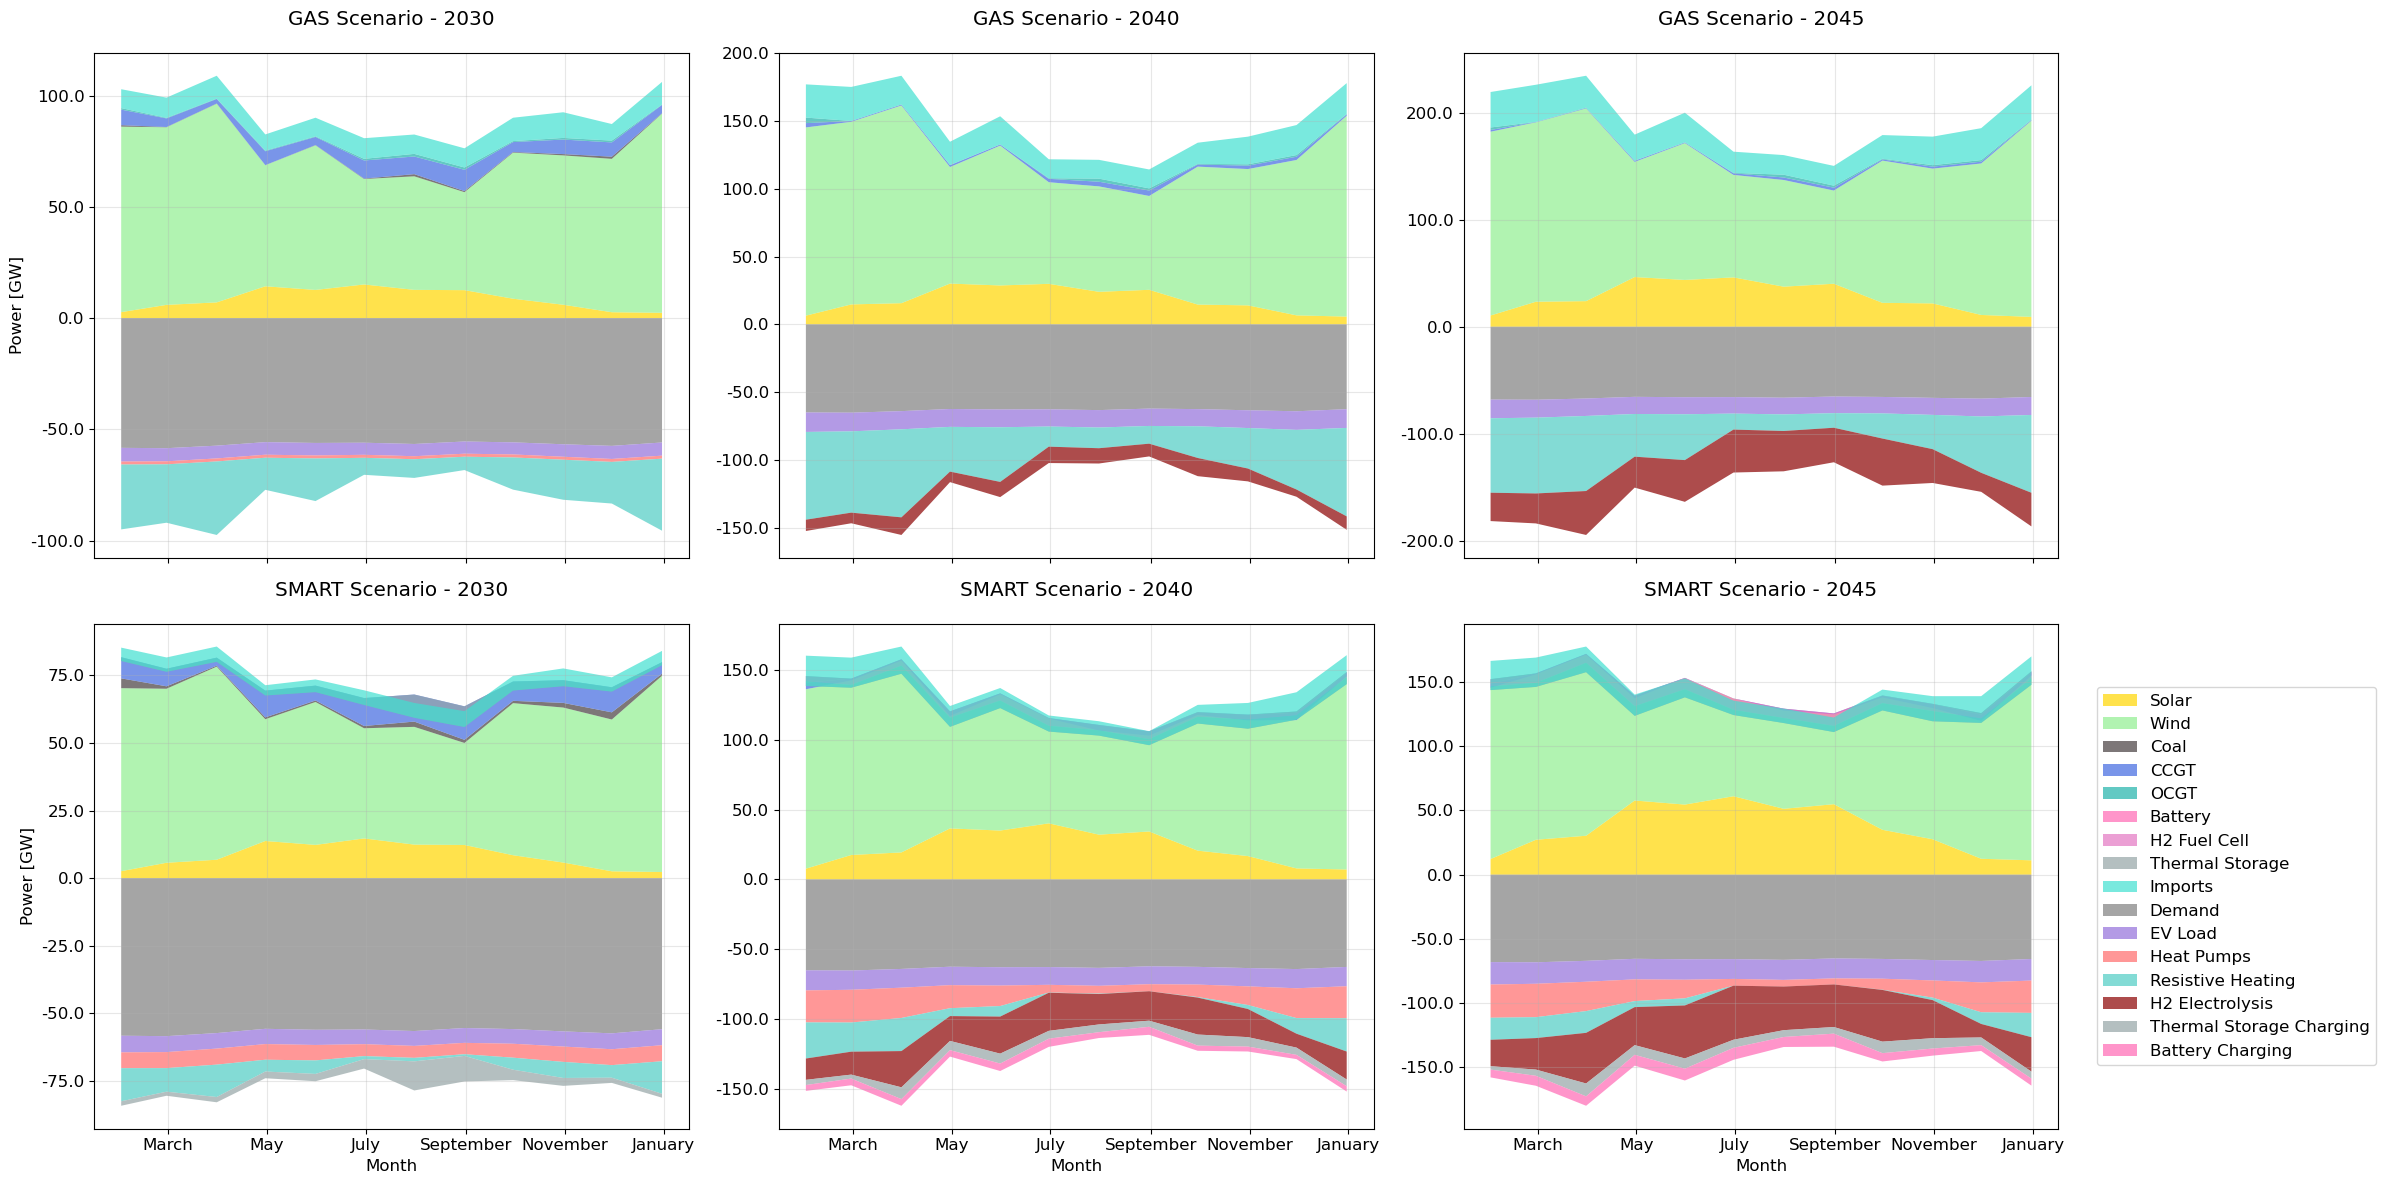

Completed monthly patterns plotting


In [9]:
import pypsa
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

def plot_energy_balance_timeseries(network_dir, output_dir, years, scenarios, first_date, second_date, show_plot=True):
    """Plot energy balance timeseries for multiple scenarios."""
    fig, axes = plt.subplots(2, 3, figsize=(24, 12), sharex=True)  # 2 rows (scenarios) x 3 columns (years)
    plt.rcParams.update({'font.size': 12})
    
    colors = {
        'solar': '#FFD700',
        'wind': '#90EE90',
        'coal': '#463E3F',
        'lignite': '#8B4513',
        'ccgt': '#4169E1',
        'ocgt': '#20B2AA',
        'battery': '#FF69B4',
        'h2_fuel_cell': '#e377c2',
        'h2_electrolyzer': '#8b0000',
        'demand': '#7f7f7f',
        'ev': '#9370DB',
        'imports': '#40E0D0',
        'heat_pumps': '#FF6B6B',
        'resistive': '#4ECDC4',
        'thermal_storage': '#95A5A6'
    }
    
    for scenario_idx, scenario in enumerate(scenarios):
        for year_idx, year in enumerate(years):
            print(f"\nProcessing {scenario} scenario, year {year}")
            
            network_file = f"{scenario}_s_27_CLL-CCL-1H_1H_{year}.nc"
            network_path = os.path.join(network_dir, network_file)
            n = pypsa.Network(network_path, engine='netcdf4')
            
            ax = axes[scenario_idx, year_idx]
            date_range = pd.date_range(first_date, second_date, freq='h')
            
            try:
                # Get German buses
                german_buses = n.buses[n.buses.index.str.startswith('DE')].index
                
                print("\nDebugging generators and links:")
                print("All link carriers:", n.links.carrier.unique())
                
                # Initialize all data series
                solar = pd.Series(0, index=date_range)
                wind = pd.Series(0, index=date_range)
                coal = pd.Series(0, index=date_range)
                ccgt = pd.Series(0, index=date_range)
                ocgt = pd.Series(0, index=date_range)
                battery_discharge = pd.Series(0, index=date_range)
                battery_charge = pd.Series(0, index=date_range)
                h2_electrolysis_load = pd.Series(0, index=date_range)
                h2_fuelcell_generation = pd.Series(0, index=date_range)
                thermal_storage_discharge = pd.Series(0, index=date_range)
                thermal_storage_charge = pd.Series(0, index=date_range)
                imports = pd.Series(0, index=date_range)
                demand = pd.Series(0, index=date_range)
                ev_load = pd.Series(0, index=date_range)
                heat_pump_load = pd.Series(0, index=date_range)
                resistive_load = pd.Series(0, index=date_range)

                # Solar generation
                solar_gens = n.generators[
                    (n.generators.bus.isin(german_buses)) & 
                    (n.generators.carrier.str.contains('solar', case=False))
                ].index
                if len(solar_gens) > 0:
                    solar = n.generators_t.p[solar_gens].sum(axis=1).reindex(date_range).fillna(0)

                # Wind generation
                wind_gens = n.generators[
                    (n.generators.bus.isin(german_buses)) & 
                    (n.generators.carrier.str.contains('wind', case=False))
                ].index
                if len(wind_gens) > 0:
                    wind = n.generators_t.p[wind_gens].sum(axis=1).reindex(date_range).fillna(0)

                # DC Imports
                dc_links = n.links[
                    (n.links.bus1.isin(german_buses)) &  
                    (n.links.carrier == 'DC')
                ].index
                if len(dc_links) > 0:
                    imports = -1 * n.links_t.p1[dc_links].sum(axis=1).reindex(date_range).fillna(0)
                    imports = imports.clip(lower=0)

                # Conventional generation
                coal_links = n.links[
                    (n.links.bus1.isin(german_buses)) &  
                    (n.links.carrier.isin(['coal', 'lignite']))
                ].index
                if len(coal_links) > 0:
                    coal = -1 * n.links_t.p1[coal_links].sum(axis=1).reindex(date_range).fillna(0)

                # CCGT
                gas_ccgt_links = n.links[
                    (n.links.bus1.isin(german_buses)) &  
                    (n.links.carrier == 'CCGT')
                ].index
                if len(gas_ccgt_links) > 0:
                    ccgt = -1 * n.links_t.p1[gas_ccgt_links].sum(axis=1).reindex(date_range).fillna(0)

                # OCGT
                gas_ocgt_links = n.links[
                    (n.links.bus1.isin(german_buses)) &  
                    (n.links.carrier == 'OCGT')
                ].index
                if len(gas_ocgt_links) > 0:
                    ocgt = -1 * n.links_t.p1[gas_ocgt_links].sum(axis=1).reindex(date_range).fillna(0)

                # Battery
                battery_discharge_links = n.links[
                    (n.links.bus0.isin(german_buses)) & 
                    (n.links.carrier.isin(['battery discharger', 'home battery discharger']))
                ].index
                if len(battery_discharge_links) > 0:
                    battery_discharge = n.links_t.p1[battery_discharge_links].sum(axis=1).reindex(date_range).fillna(0)

                battery_charge_links = n.links[
                    (n.links.bus0.isin(german_buses)) & 
                    (n.links.carrier.isin(['battery charger', 'home battery charger']))
                ].index
                if len(battery_charge_links) > 0:
                    battery_charge = n.links_t.p0[battery_charge_links].sum(axis=1).reindex(date_range).fillna(0) * -1

                # H2 System
                h2_electrolysis_links = n.links[
                    (n.links.bus0.isin(german_buses)) & 
                    (n.links.carrier == 'H2 Electrolysis')
                ].index
                if len(h2_electrolysis_links) > 0:
                    h2_electrolysis_load = n.links_t.p0[h2_electrolysis_links].sum(axis=1).reindex(date_range).fillna(0) * -1

                h2_fuelcell_links = n.links[
                    (n.links.bus0.isin(german_buses)) & 
                    (n.links.carrier == 'H2 Fuel Cell')
                ].index
                if len(h2_fuelcell_links) > 0:
                    h2_fuelcell_generation = n.links_t.p1[h2_fuelcell_links].sum(axis=1).reindex(date_range).fillna(0)

                # Heat pumps load
                heat_pump_types = [
                    'urban central air heat pump',
                    'urban decentral air heat pump',
                    'rural ground heat pump',
                    'rural air heat pump'
                ]
                for hp_type in heat_pump_types:
                    hp_links = n.links[
                        (n.links.bus0.isin(german_buses)) & 
                        (n.links.carrier == hp_type)
                    ].index
                    if len(hp_links) > 0:
                        hp_load = n.links_t.p0[hp_links].sum(axis=1).reindex(date_range).fillna(0)
                        heat_pump_load += hp_load

                # Resistive heaters load
                resistive_types = [
                    'urban central resistive heater',
                    'urban decentral resistive heater',
                    'rural resistive heater'
                ]
                for res_type in resistive_types:
                    res_links = n.links[
                        (n.links.bus0.isin(german_buses)) & 
                        (n.links.carrier == res_type)
                    ].index
                    if len(res_links) > 0:
                        res_load = n.links_t.p0[res_links].sum(axis=1).reindex(date_range).fillna(0)
                        resistive_load += res_load

                # Thermal Storage
                thermal_storage_charge_types = [
                    'urban central water tanks charger',
                    'urban decentral water tanks charger',
                    'rural water tanks charger'
                ]
                for ts_type in thermal_storage_charge_types:
                    ts_links = n.links[
                        (n.links.bus0.isin(german_buses)) & 
                        (n.links.carrier == ts_type)
                    ].index
                    if len(ts_links) > 0:
                        ts_load = n.links_t.p0[ts_links].sum(axis=1).reindex(date_range).fillna(0)
                        thermal_storage_charge += ts_load

                thermal_storage_discharge_types = [
                    'urban central water tanks discharger',
                    'urban decentral water tanks discharger',
                    'rural water tanks discharger'
                ]
                for ts_type in thermal_storage_discharge_types:
                    ts_links = n.links[
                        (n.links.bus0.isin(german_buses)) & 
                        (n.links.carrier == ts_type)
                    ].index
                    if len(ts_links) > 0:
                        ts_gen = n.links_t.p1[ts_links].sum(axis=1).reindex(date_range).fillna(0)
                        thermal_storage_discharge += ts_gen

                # EV load calculation
                ev_load_indices = n.loads[
                    (n.loads.bus.isin(german_buses)) & 
                    (n.loads.carrier == 'land transport EV')
                ].index
                if len(ev_load_indices) > 0:
                    if hasattr(n.loads_t, 'p'):
                        ev_load = n.loads_t.p[ev_load_indices].sum(axis=1).reindex(date_range).fillna(0)
                    elif hasattr(n.loads_t, 'p_set'):
                        ev_load = n.loads_t.p_set[ev_load_indices].sum(axis=1).reindex(date_range).fillna(0)
                ev_load = ev_load * -1

                # Regular demand
                electrical_load_types = [
                    'electricity',
                    'industry electricity',
                    'agriculture electricity'
                ]
                
                print("\nCalculating demand for loads:")
                for load_type in electrical_load_types:
                    load_indices = n.loads[
                        (n.loads.bus.isin(german_buses)) & 
                        (n.loads.carrier == load_type)
                    ].index
                    if len(load_indices) > 0:
                        if hasattr(n.loads_t, 'p'):
                            load_value = n.loads_t.p[load_indices].sum(axis=1).reindex(date_range).fillna(0)
                        elif hasattr(n.loads_t, 'p_set'):
                            load_value = n.loads_t.p_set[load_indices].sum(axis=1).reindex(date_range).fillna(0)
                        demand += load_value
                        print(f"{load_type}: {load_value.min():.2f} to {load_value.max():.2f}")
                demand = demand * -1

                # Print data ranges
                print(f"\nData ranges for {year}:")
                print(f"Solar: {solar.min():.2f} to {solar.max():.2f}")
                print(f"Wind: {wind.min():.2f} to {wind.max():.2f}")
                print(f"Coal: {coal.min():.2f} to {coal.max():.2f}")
                print(f"CCGT: {ccgt.min():.2f} to {ccgt.max():.2f}")
                print(f"OCGT: {ocgt.min():.2f} to {ocgt.max():.2f}")
                print(f"Battery discharge: {battery_discharge.min():.2f} to {battery_discharge.max():.2f}")
                print(f"H2 Fuel Cell: {h2_fuelcell_generation.min():.2f} to {h2_fuelcell_generation.max():.2f}")
                print(f"H2 Electrolysis: {h2_electrolysis_load.min():.2f} to {h2_electrolysis_load.max():.2f}")
                print(f"Regular demand: {demand.min():.2f} to {demand.max():.2f}")
                print(f"EV demand: {ev_load.min():.2f} to {ev_load.max():.2f}")
                print(f"Heat Pump load: {heat_pump_load.min():.2f} to {heat_pump_load.max():.2f}")
                print(f"Resistive heating: {resistive_load.min():.2f} to {resistive_load.max():.2f}")
                print(f"Thermal storage charge: {thermal_storage_charge.min():.2f} to {thermal_storage_charge.max():.2f}")
                print(f"Thermal storage discharge: {thermal_storage_discharge.min():.2f} to {thermal_storage_discharge.max():.2f}")
                print(f"Imports: {imports.min():.2f} to {imports.max():.2f}")

                # Plot supply stack
                supply_data = [
                    solar, wind, coal, ccgt, ocgt,
                    battery_discharge, h2_fuelcell_generation,
                    thermal_storage_discharge, imports
                ]
                
                supply_labels = [
                    'Solar', 'Wind', 'Coal', 'CCGT', 'OCGT', 
                    'Battery', 'H2 Fuel Cell', 'Thermal Storage', 'Imports'
                ]
                supply_colors = [colors[label.lower().replace(' ', '_')] for label in supply_labels]
                
                ax.stackplot(
                    date_range,
                    supply_data,
                    labels=supply_labels,
                    colors=supply_colors,
                    alpha=0.7
                )

                # Plot demand stack
                demand_data = [
                    demand, ev_load, heat_pump_load * -1,
                    resistive_load * -1, h2_electrolysis_load,
                    thermal_storage_charge * -1, battery_charge
                ]
                
                demand_labels = [
                    'Demand', 'EV Load', 'Heat Pumps',
                    'Resistive Heating', 'H2 Electrolysis',
                    'Thermal Storage Charging', 'Battery Charging'
                ]
                
                demand_colors = [
                    colors['demand'], colors['ev'],
                    colors['heat_pumps'], colors['resistive'],
                    colors['h2_electrolyzer'], colors['thermal_storage'],
                    colors['battery']
                ]
                
                ax.stackplot(
                    date_range,
                    demand_data,
                    labels=demand_labels,
                    colors=demand_colors,
                    alpha=0.7
                )

            except Exception as e:
                print(f"Error processing year {year}: {str(e)}")
                import traceback
                traceback.print_exc()
                continue

            # Plot formatting
            ax.set_title(f'{scenario.upper()} Scenario - {year}', pad=20)
            if scenario_idx == len(scenarios)-1:
                ax.set_xlabel('Date', fontsize=12)
            if year_idx == 0:
                ax.set_ylabel('Power [GW]', fontsize=12)
            
            ax.grid(True, alpha=0.3)
            
            # Format y-axis
            scale_y = 1e3
            ax.yaxis.set_major_formatter(
                ticker.FuncFormatter(lambda x, pos: f'{x/scale_y:.1f}')
            )
            
            # Only show legend for the last subplot
            if scenario_idx == len(scenarios)-1 and year_idx == len(years)-1:
                handles, labels = ax.get_legend_handles_labels()
                unique_labels = dict(zip(labels, handles))
                ax.legend(
                    unique_labels.values(),
                    unique_labels.keys(),
                    loc='center left',
                    bbox_to_anchor=(1.05, 0.5)
                )

    plt.tight_layout()
    
    # Save plots
    plt.savefig(os.path.join(output_dir, f'energy_balance_timeseries_all_scenarios.png'), 
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, f'energy_balance_timeseries_all_scenarios.pdf'), 
                bbox_inches='tight')
    
    # Display plot
    if show_plot:
        plt.show()
    else:
        plt.close()

def plot_yearly_monthly_patterns(network_dir, output_dir, years, scenarios, show_plot=True):
    """Plot energy balance patterns for all months in the year for multiple scenarios."""
    fig, axes = plt.subplots(2, 3, figsize=(24, 12), sharex=True)  # 2 rows (scenarios) x 3 columns (years)
    plt.rcParams.update({'font.size': 12})
    
    # Update the frequency to 'ME' (Month End) instead of 'M'
    months_index = pd.date_range(start=f'2019-01-01', end=f'2019-12-31', freq='ME')
    
    colors = {
        'solar': '#FFD700',
        'wind': '#90EE90',
        'coal': '#463E3F',
        'lignite': '#8B4513',
        'ccgt': '#4169E1',
        'ocgt': '#20B2AA',
        'battery': '#FF69B4',
        'h2_fuel_cell': '#e377c2',
        'h2_electrolyzer': '#8b0000',
        'demand': '#7f7f7f',
        'ev': '#9370DB',
        'imports': '#40E0D0',
        'heat_pumps': '#FF6B6B',
        'resistive': '#4ECDC4',
        'thermal_storage': '#95A5A6'
    }
    
    def get_monthly_averages(series):
        monthly_means = []
        for month in range(1, 13):
            month_data = series[series.index.month == month]
            monthly_means.append(month_data.mean())
        return pd.Series(monthly_means, index=months_index)
    
    for scenario_idx, scenario in enumerate(scenarios):
        for year_idx, year in enumerate(years):
            print(f"\nProcessing {scenario} scenario, year {year}")
            
            network_file = f"{scenario}_s_27_CLL-CCL-1H_1H_{year}.nc"
            network_path = os.path.join(network_dir, network_file)
            n = pypsa.Network(network_path, engine='netcdf4')
            
            ax = axes[scenario_idx, year_idx]
            
            try:
                # Get German buses
                german_buses = n.buses[n.buses.index.str.startswith('DE')].index
                
                # Initialize monthly averages
                solar_monthly = pd.Series(0, index=months_index)
                wind_monthly = pd.Series(0, index=months_index)
                coal_monthly = pd.Series(0, index=months_index)
                ccgt_monthly = pd.Series(0, index=months_index)
                ocgt_monthly = pd.Series(0, index=months_index)
                battery_discharge_monthly = pd.Series(0, index=months_index)
                battery_charge_monthly = pd.Series(0, index=months_index)
                h2_electrolysis_monthly = pd.Series(0, index=months_index)
                h2_fuelcell_monthly = pd.Series(0, index=months_index)
                thermal_discharge_monthly = pd.Series(0, index=months_index)
                thermal_charge_monthly = pd.Series(0, index=months_index)
                imports_monthly = pd.Series(0, index=months_index)
                demand_monthly = pd.Series(0, index=months_index)
                ev_monthly = pd.Series(0, index=months_index)
                heat_pump_monthly = pd.Series(0, index=months_index)
                resistive_monthly = pd.Series(0, index=months_index)

                # Solar generation
                solar_gens = n.generators[
                    (n.generators.bus.isin(german_buses)) & 
                    (n.generators.carrier.str.contains('solar', case=False))
                ].index
                if len(solar_gens) > 0:
                    solar = n.generators_t.p[solar_gens].sum(axis=1)
                    solar_monthly = get_monthly_averages(solar)

                # Wind generation
                wind_gens = n.generators[
                    (n.generators.bus.isin(german_buses)) & 
                    (n.generators.carrier.str.contains('wind', case=False))
                ].index
                if len(wind_gens) > 0:
                    wind = n.generators_t.p[wind_gens].sum(axis=1)
                    wind_monthly = get_monthly_averages(wind)

                # DC Imports
                dc_links = n.links[
                    (n.links.bus1.isin(german_buses)) &  
                    (n.links.carrier == 'DC')
                ].index
                if len(dc_links) > 0:
                    imports = -1 * n.links_t.p1[dc_links].sum(axis=1)
                    imports = imports.clip(lower=0)
                    imports_monthly = get_monthly_averages(imports)

                # Conventional generation
                coal_links = n.links[
                    (n.links.bus1.isin(german_buses)) &  
                    (n.links.carrier.isin(['coal', 'lignite']))
                ].index
                if len(coal_links) > 0:
                    coal = -1 * n.links_t.p1[coal_links].sum(axis=1)
                    coal_monthly = get_monthly_averages(coal)

                # CCGT
                gas_ccgt_links = n.links[
                    (n.links.bus1.isin(german_buses)) &  
                    (n.links.carrier == 'CCGT')
                ].index
                if len(gas_ccgt_links) > 0:
                    ccgt = -1 * n.links_t.p1[gas_ccgt_links].sum(axis=1)
                    ccgt_monthly = get_monthly_averages(ccgt)

                # OCGT
                gas_ocgt_links = n.links[
                    (n.links.bus1.isin(german_buses)) &  
                    (n.links.carrier == 'OCGT')
                ].index
                if len(gas_ocgt_links) > 0:
                    ocgt = -1 * n.links_t.p1[gas_ocgt_links].sum(axis=1)
                    ocgt_monthly = get_monthly_averages(ocgt)

                # Battery
                battery_discharge_links = n.links[
                    (n.links.bus0.isin(german_buses)) & 
                    (n.links.carrier.isin(['battery discharger', 'home battery discharger']))
                ].index
                if len(battery_discharge_links) > 0:
                    battery_discharge = n.links_t.p1[battery_discharge_links].sum(axis=1)
                    battery_discharge_monthly = get_monthly_averages(battery_discharge)

                battery_charge_links = n.links[
                    (n.links.bus0.isin(german_buses)) & 
                    (n.links.carrier.isin(['battery charger', 'home battery charger']))
                ].index
                if len(battery_charge_links) > 0:
                    battery_charge = n.links_t.p0[battery_charge_links].sum(axis=1) * -1
                    battery_charge_monthly = get_monthly_averages(battery_charge)

                # H2 System
                h2_electrolysis_links = n.links[
                    (n.links.bus0.isin(german_buses)) & 
                    (n.links.carrier == 'H2 Electrolysis')
                ].index
                if len(h2_electrolysis_links) > 0:
                    h2_electrolysis = n.links_t.p0[h2_electrolysis_links].sum(axis=1) * -1
                    h2_electrolysis_monthly = get_monthly_averages(h2_electrolysis)

                h2_fuelcell_links = n.links[
                    (n.links.bus0.isin(german_buses)) & 
                    (n.links.carrier == 'H2 Fuel Cell')
                ].index
                if len(h2_fuelcell_links) > 0:
                    h2_fuelcell = n.links_t.p1[h2_fuelcell_links].sum(axis=1)
                    h2_fuelcell_monthly = get_monthly_averages(h2_fuelcell)

                # Heat pumps and resistive heating
                heat_pump_load = pd.Series(0, index=n.snapshots)
                heat_pump_types = [
                    'urban central air heat pump',
                    'urban decentral air heat pump',
                    'rural ground heat pump',
                    'rural air heat pump'
                ]
                for hp_type in heat_pump_types:
                    hp_links = n.links[
                        (n.links.bus0.isin(german_buses)) & 
                        (n.links.carrier == hp_type)
                    ].index
                    if len(hp_links) > 0:
                        heat_pump_load += n.links_t.p0[hp_links].sum(axis=1)
                heat_pump_monthly = get_monthly_averages(heat_pump_load)

                resistive_load = pd.Series(0, index=n.snapshots)
                resistive_types = [
                    'urban central resistive heater',
                    'urban decentral resistive heater',
                    'rural resistive heater'
                ]
                for res_type in resistive_types:
                    res_links = n.links[
                        (n.links.bus0.isin(german_buses)) & 
                        (n.links.carrier == res_type)
                    ].index
                    if len(res_links) > 0:
                        resistive_load += n.links_t.p0[res_links].sum(axis=1)
                resistive_monthly = get_monthly_averages(resistive_load)

                # Thermal Storage
                thermal_storage_charge = pd.Series(0, index=n.snapshots)
                thermal_storage_discharge = pd.Series(0, index=n.snapshots)
                
                thermal_storage_charge_types = [
                    'urban central water tanks charger',
                    'urban decentral water tanks charger',
                    'rural water tanks charger'
                ]
                for ts_type in thermal_storage_charge_types:
                    ts_links = n.links[
                        (n.links.bus0.isin(german_buses)) & 
                        (n.links.carrier == ts_type)
                    ].index
                    if len(ts_links) > 0:
                        thermal_storage_charge += n.links_t.p0[ts_links].sum(axis=1)
                thermal_charge_monthly = get_monthly_averages(thermal_storage_charge)

                thermal_storage_discharge_types = [
                    'urban central water tanks discharger',
                    'urban decentral water tanks discharger',
                    'rural water tanks discharger'
                ]
                for ts_type in thermal_storage_discharge_types:
                    ts_links = n.links[
                        (n.links.bus0.isin(german_buses)) & 
                        (n.links.carrier == ts_type)
                    ].index
                    if len(ts_links) > 0:
                        thermal_storage_discharge += n.links_t.p1[ts_links].sum(axis=1)
                thermal_discharge_monthly = get_monthly_averages(thermal_storage_discharge)

                # Regular demand and EV load
                demand = pd.Series(0, index=n.snapshots)
                electrical_load_types = [
                    'electricity',
                    'industry electricity',
                    'agriculture electricity'
                ]
                for load_type in electrical_load_types:
                    load_indices = n.loads[
                        (n.loads.bus.isin(german_buses)) & 
                        (n.loads.carrier == load_type)
                    ].index
                    if len(load_indices) > 0:
                        if hasattr(n.loads_t, 'p'):
                            demand += n.loads_t.p[load_indices].sum(axis=1)
                        elif hasattr(n.loads_t, 'p_set'):
                            demand += n.loads_t.p_set[load_indices].sum(axis=1)
                demand = demand * -1
                demand_monthly = get_monthly_averages(demand)

                ev_load = pd.Series(0, index=n.snapshots)
                ev_load_indices = n.loads[
                    (n.loads.bus.isin(german_buses)) & 
                    (n.loads.carrier == 'land transport EV')
                ].index
                if len(ev_load_indices) > 0:
                    if hasattr(n.loads_t, 'p'):
                        ev_load = n.loads_t.p[ev_load_indices].sum(axis=1)
                    elif hasattr(n.loads_t, 'p_set'):
                        ev_load = n.loads_t.p_set[ev_load_indices].sum(axis=1)
                ev_load = ev_load * -1
                ev_monthly = get_monthly_averages(ev_load)

                # Plot supply stack
                supply_data = [
                    solar_monthly, wind_monthly, coal_monthly,
                    ccgt_monthly, ocgt_monthly, battery_discharge_monthly,
                    h2_fuelcell_monthly, thermal_discharge_monthly,
                    imports_monthly
                ]
                
                supply_labels = [
                    'Solar', 'Wind', 'Coal', 'CCGT', 'OCGT', 
                    'Battery', 'H2 Fuel Cell', 'Thermal Storage', 'Imports'
                ]
                supply_colors = [colors[label.lower().replace(' ', '_')] for label in supply_labels]
                
                ax.stackplot(
                    months_index,
                    supply_data,
                    labels=supply_labels,
                    colors=supply_colors,
                    alpha=0.7
                )
                
                # Plot demand stack
                demand_data = [
                    demand_monthly, ev_monthly,
                    heat_pump_monthly * -1, resistive_monthly * -1,
                    h2_electrolysis_monthly, thermal_charge_monthly * -1,
                    battery_charge_monthly
                ]
                
                demand_labels = [
                    'Demand', 'EV Load', 'Heat Pumps',
                    'Resistive Heating', 'H2 Electrolysis',
                    'Thermal Storage Charging', 'Battery Charging'
                ]
                
                demand_colors = [
                    colors['demand'], colors['ev'],
                    colors['heat_pumps'], colors['resistive'],
                    colors['h2_electrolyzer'], colors['thermal_storage'],
                    colors['battery']
                ]
                
                ax.stackplot(
                    months_index,
                    demand_data,
                    labels=demand_labels,
                    colors=demand_colors,
                    alpha=0.7
                )

            except Exception as e:
                print(f"Error processing year {year}: {str(e)}")
                import traceback
                traceback.print_exc()
                continue

            # Plot formatting
            ax.set_title(f'{scenario.upper()} Scenario - {year}', pad=20)
            if scenario_idx == len(scenarios)-1:
                ax.set_xlabel('Month', fontsize=12)
            if year_idx == 0:
                ax.set_ylabel('Power [GW]', fontsize=12)
            
            ax.grid(True, alpha=0.3)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
            
            # Format y-axis
            scale_y = 1e3
            ax.yaxis.set_major_formatter(
                ticker.FuncFormatter(lambda x, pos: f'{x/scale_y:.1f}')
            )
            
            # Only show legend for the last subplot
            if scenario_idx == len(scenarios)-1 and year_idx == len(years)-1:
                handles, labels = ax.get_legend_handles_labels()
                unique_labels = dict(zip(labels, handles))
                ax.legend(
                    unique_labels.values(),
                    unique_labels.keys(),
                    loc='center left',
                    bbox_to_anchor=(1.05, 0.5)
                )

    plt.tight_layout()
    
    # Save plots
    plt.savefig(os.path.join(output_dir, 'energy_balance_monthly_averages.png'), 
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(output_dir, 'energy_balance_monthly_averages.pdf'), 
                bbox_inches='tight')
    
    # Display plot
    if show_plot:
        plt.show()
    else:
        plt.close()

# Usage example
if __name__ == "__main__":
    # Update paths and scenarios
    network_dir = "/home/mohsen/PycharmProjects/PyPSA-Eur/pypsa-eur-flexibility/results/scenario/gas-smart-myopic/networks"
    output_dir = "/home/mohsen/PycharmProjects/PyPSA-Eur/pypsa-eur-flexibility/results/scenario/gas-smart-myopic/germany_statistics_output"
    
    years = [2030, 2040, 2045]
    scenarios = ['gas', 'smart']
    
    # Verify files exist
    for scenario in scenarios:
        for year in years:
            filename = f"{scenario}_s_27_CLL-CCL-1H_1H_{year}.nc"
            filepath = os.path.join(network_dir, filename)
            if not os.path.exists(filepath):
                print(f"Warning: File not found: {filepath}")
                continue
    
    try:
        plot_energy_balance_timeseries(
            network_dir, 
            output_dir, 
            years,
            scenarios,
            first_date="2019-03-01", 
            second_date="2019-3-15"
        )
        print("Completed timeseries plotting")
        
        plot_yearly_monthly_patterns(network_dir, output_dir, years, scenarios)
        print("Completed monthly patterns plotting")
        
    except Exception as e:
        print(f"Error occurred: {str(e)}")
        import traceback
        traceback.print_exc()


Processing gas scenario, year 2030


INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2030.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Component costs found (before scaling):
Solar capital cost: 11376213438.64
Wind Onshore capital cost: 13307779559.57
Wind Offshore capital cost: 8283134612.07
CCGT capital cost: 2797336543.69
OCGT capital cost: 345855678.39
Coal capital cost: 1780458384.93
H2 Fuel Cell capital cost: 736.59
H2 Storage capital cost: 886.29
Heat Pumps capital cost: 619400247.99
Transmission capital cost: 3602178335.26
H2 Pipeline capital cost: 160567.75

Processing gas scenario, year 2040


INFO:pypsa.io:Imported network gas_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Component costs found (before scaling):
Solar capital cost: 19282550459.19
Wind Onshore capital cost: 18399451738.89
Wind Offshore capital cost: 10075271477.71
CCGT capital cost: 2245600998.11
OCGT capital cost: 4010930500.62
H2 Fuel Cell capital cost: 28138.65
H2 Storage capital cost: 92590085.55
Transmission capital cost: 5049149792.11
H2 Pipeline capital cost: 212788560.33

Processing gas scenario, year 2045


...


Component costs found (before scaling):
Solar capital cost: 11257202063.35
Wind Onshore capital cost: 13307779559.57
Wind Offshore capital cost: 8283134382.47
CCGT capital cost: 2797336543.69
OCGT capital cost: 1780393.37
Coal capital cost: 1780458384.93
H2 Fuel Cell capital cost: 12.42
Battery Storage capital cost: 102.46
H2 Storage capital cost: 17.07
Heat Pumps capital cost: 2629544655.54
Transmission capital cost: 3127412914.55
H2 Pipeline capital cost: 153850.14

Processing smart scenario, year 2040


INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2040.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Component costs found (before scaling):
Solar capital cost: 20426061143.02
Wind Onshore capital cost: 18399451738.89
Wind Offshore capital cost: 10075265020.11
CCGT capital cost: 2245600998.11
OCGT capital cost: 2571997712.72
H2 Fuel Cell capital cost: 1.40
Battery Storage capital cost: 1856322041.00
H2 Storage capital cost: 74713503.39
Heat Pumps capital cost: 9314978293.18
Transmission capital cost: 4489397737.66
H2 Pipeline capital cost: 216327923.80

Processing smart scenario, year 2045


INFO:pypsa.io:Imported network smart_s_27_CLL-CCL-1H_1H_2045.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores



Component costs found (before scaling):
Solar capital cost: 22206270060.51
Wind Onshore capital cost: 18515171561.14
Wind Offshore capital cost: 8650411768.14
CCGT capital cost: 1807789312.11
OCGT capital cost: 2571997475.34
H2 Fuel Cell capital cost: 69.76
Battery Storage capital cost: 2582708446.88
H2 Storage capital cost: 114675527.61
Heat Pumps capital cost: 10042304583.19
Transmission capital cost: 4577157229.75
H2 Pipeline capital cost: 281787269.59

Total costs for gas scenario by year [billion EUR]:
2030    42.392494
2040    59.524618
2045    61.399858
dtype: float64

Total costs for gas scenario by category [billion EUR]:
2030    42.392494
2040    59.524618
2045    61.399858
dtype: float64

Total costs for smart scenario by year [billion EUR]:
2030    43.546770
2040    69.837852
2045    71.497338
dtype: float64

Total costs for smart scenario by category [billion EUR]:
2030    43.546770
2040    69.837852
2045    71.497338
dtype: float64


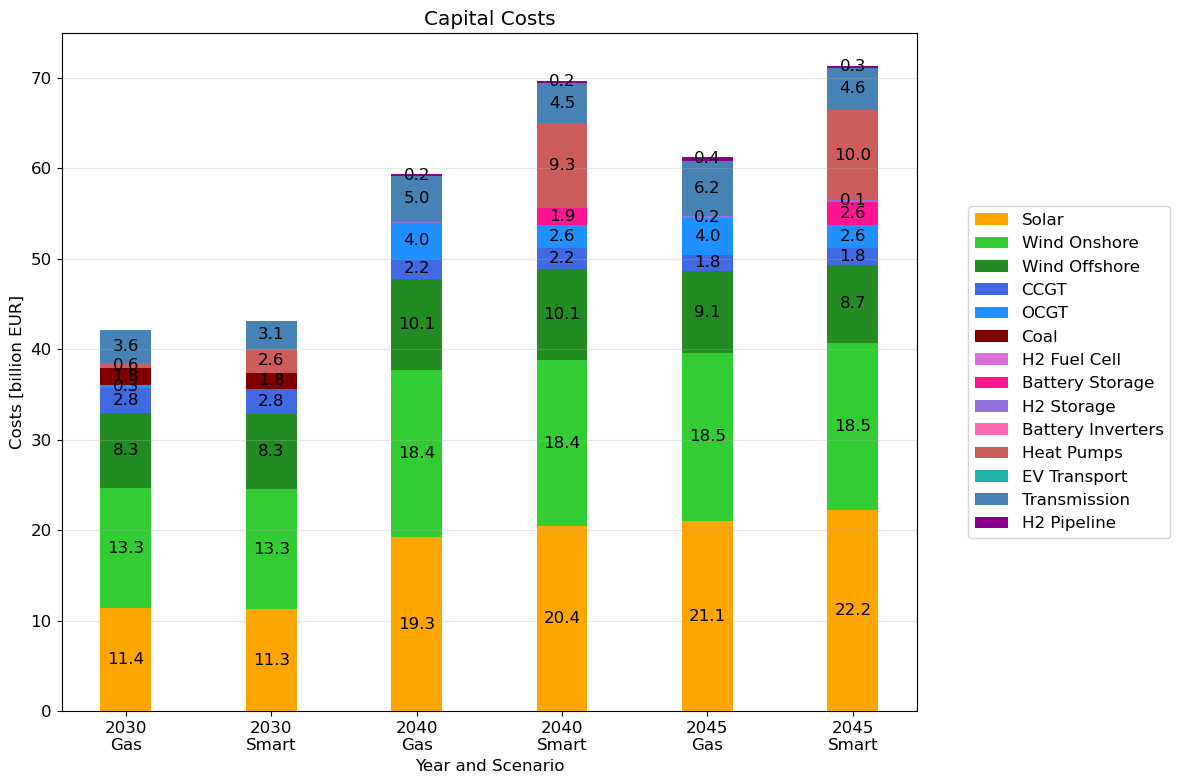

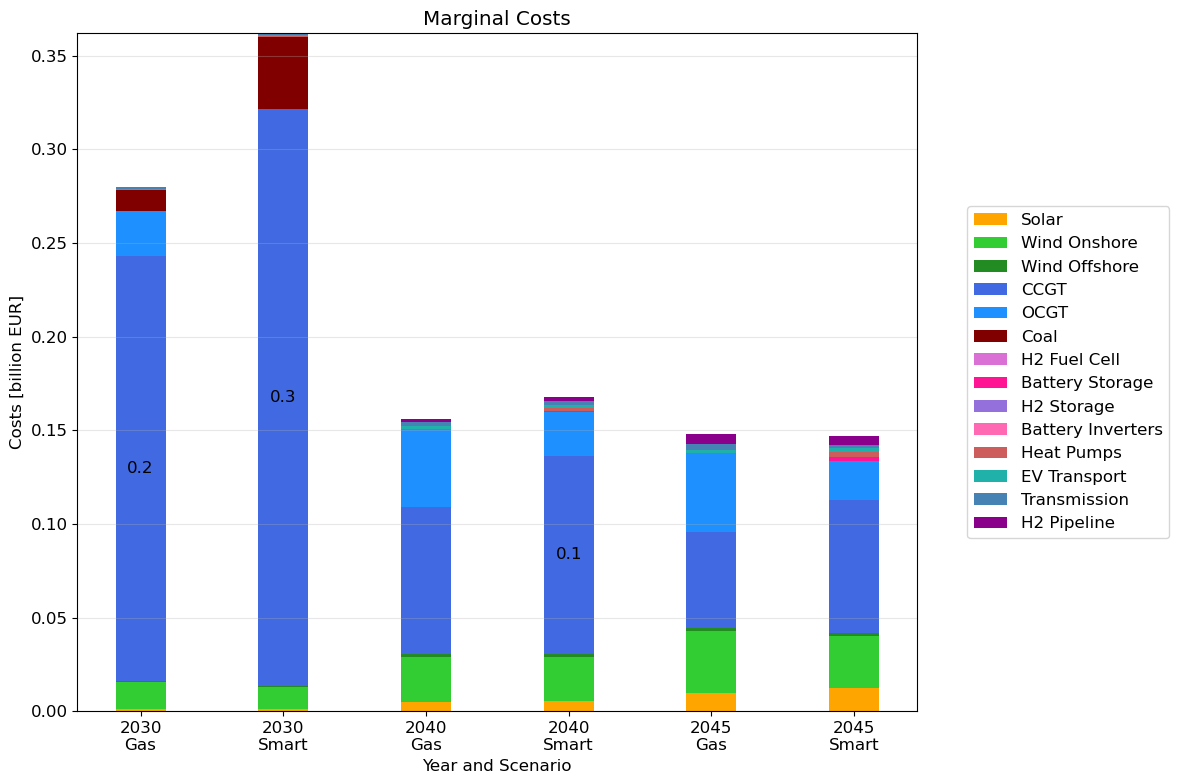

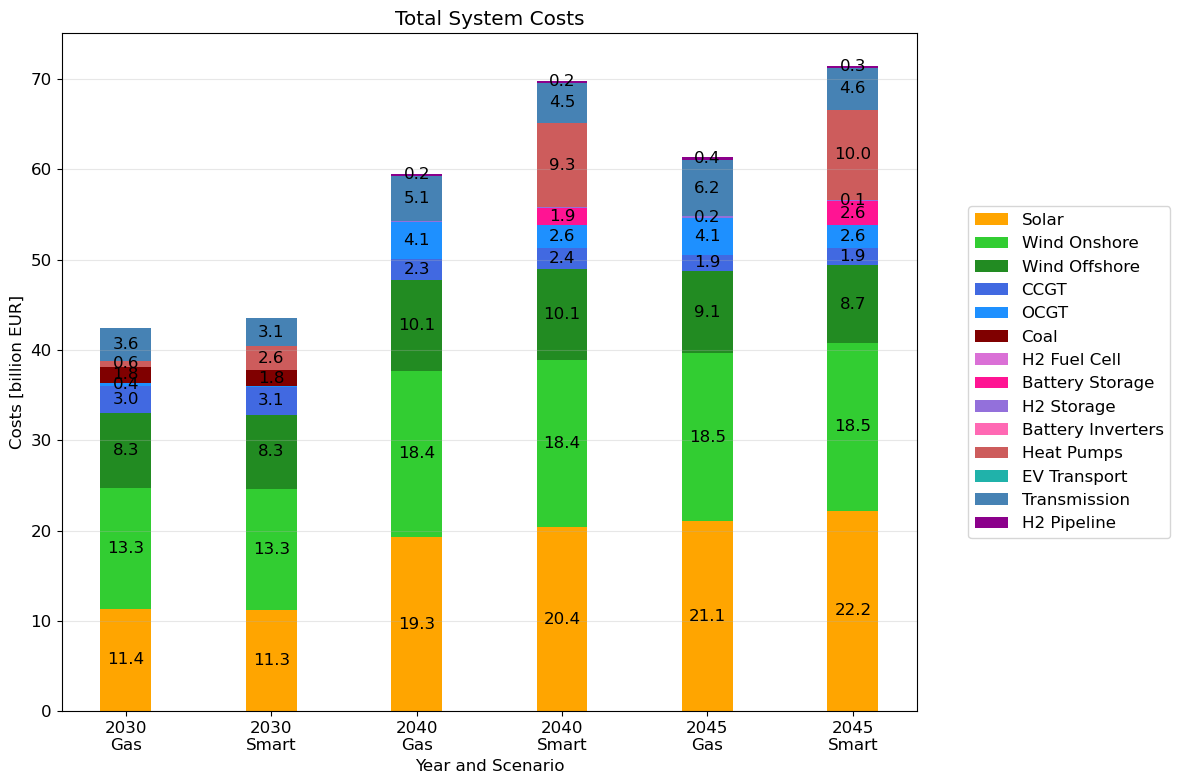

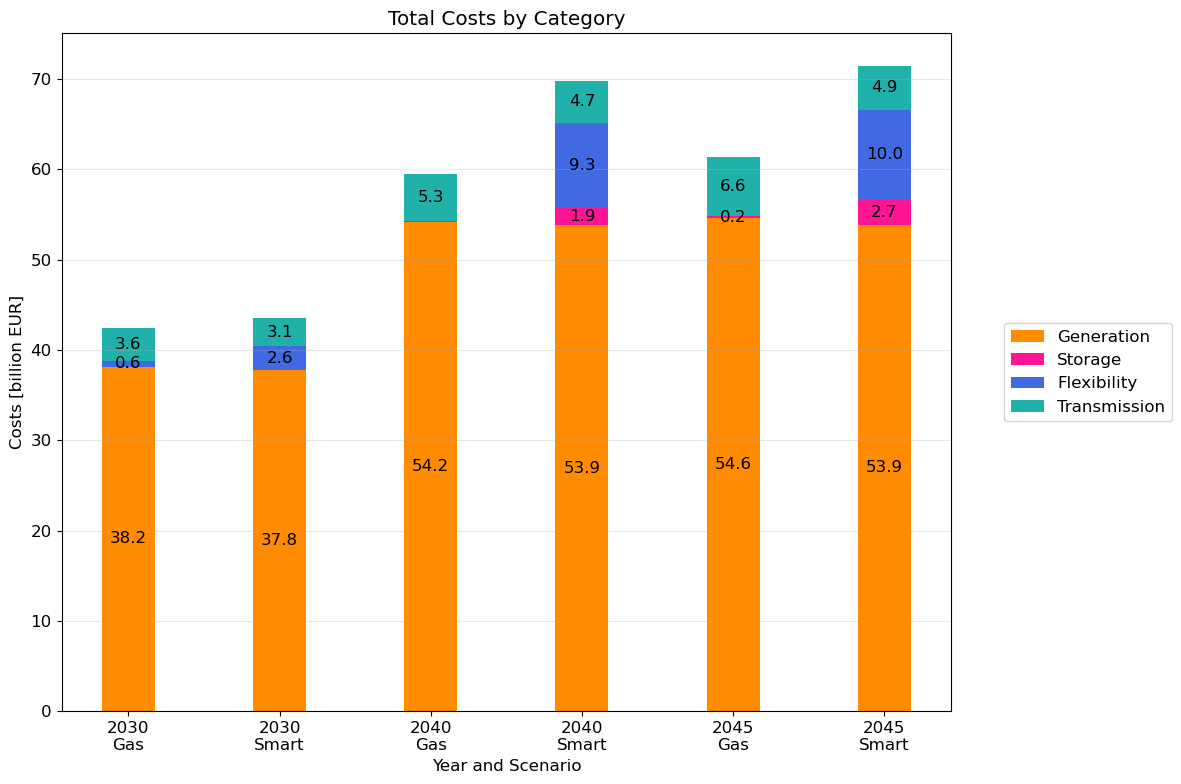

In [12]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Updated categories dictionary
categories = {
    'Generation': {
        'Solar': ['solar'],
        'Wind Onshore': ['onwind'],
        'Wind Offshore': ['offwind'],
        'CCGT': ['CCGT'],
        'OCGT': ['OCGT'],
        'Coal': ['coal', 'lignite'],
        'H2 Fuel Cell': ['H2 Fuel Cell'],
    },
    'Storage': {
        'Battery Storage': ['battery', 'EV battery', 'home battery'],
        'H2 Storage': ['H2 Store'],
        'Battery Inverters': ['battery charger', 'battery discharger', 
                            'home battery charger', 'home battery discharger'],
    },
    'Flexibility': {
        #'H2 Electrolysis': ['H2 Electrolysis'],
        'Heat Pumps': ['heat pump'],
        'EV Transport': ['BEV Charger', 'V2G'],
    },
    'Transmission': {
        'Transmission': ['DC', 'AC'],
        'H2 Pipeline': ['H2 pipeline'],
    }
}

# Updated color schemes
detailed_colors = {
    # Generation
    'Solar': '#FFA500',          # Orange
    'Wind Onshore': '#32CD32',   # Lime Green
    'Wind Offshore': '#228B22',  # Forest Green
    'CCGT': '#4169E1',          # Royal Blue
    'OCGT': '#1E90FF',          # Dodger Blue
    'Coal': '#800000',          # Maroon
    'H2 Fuel Cell': '#DA70D6',  # Orchid

    # Storage
    'Battery Storage': '#FF1493',# Deep Pink
    'H2 Storage': '#9370DB',    # Medium Purple
    'Battery Inverters': '#FF69B4', # Hot Pink

    # Flexibility
    #'H2 Electrolysis': '#FF4500',# Orange Red
    'Heat Pumps': '#CD5C5C',    # Indian Red
    'EV Transport': '#20B2AA',   # Light Sea Green

    # Transmission
    'Transmission': '#4682B4',   # Steel Blue
    'H2 Pipeline': '#8B008B'    # Dark Magenta
}

aggregated_colors = {
    'Generation': '#FF8C00',     # Dark Orange
    'Storage': '#FF1493',        # Deep Pink
    'Flexibility': '#4169E1',    # Royal Blue
    'Transmission': '#20B2AA'    # Light Sea Green
}

def calculate_detailed_costs(n, german_buses):
    """Calculate capital and marginal costs with detailed categorization."""
    
    # Initialize cost dictionaries
    capital_costs = {cat: 0 for subdict in categories.values() for cat in subdict.keys()}
    marginal_costs = {cat: 0 for subdict in categories.values() for cat in subdict.keys()}
    
    def process_component(component, comp_type):
        """
        Process component to determine its category.
        """
        carrier = str(component.carrier).lower() if hasattr(component, 'carrier') else ''
        name = str(component.name).lower() if hasattr(component, 'name') else ''
        
        # Direct matching for specific components
        if 'H2 Store' in carrier or 'H2 Store' in name:
            return 'H2 Storage', 'Storage'
        #elif 'H2 Electrolysis' in carrier or 'H2 Electrolysis' in name:
            #return 'H2 Electrolysis', 'Flexibility'
        elif 'H2 Fuel Cell' in carrier or 'H2 Fuel Cell' in name:
            return 'H2 Fuel Cell', 'Generation'
        elif 'H2 pipeline' in carrier or 'H2 pipeline' in name:
            return 'H2 Pipeline', 'Transmission'
        elif any(ev in carrier or ev in name for ev in ['BEV Charger', 'V2G']):
            return 'EV Transport', 'Flexibility'
        
        # General matching for other components
        for main_cat, subcat_dict in categories.items():
            for subcat, keywords in subcat_dict.items():
                if any(keyword.lower() in carrier for keyword in keywords) or \
                   any(keyword.lower() in name for keyword in keywords):
                    return subcat, main_cat
        return None, None

    try:
        # Process generators
        generators = n.generators[n.generators.bus.isin(german_buses)]
        for idx, gen in generators.iterrows():
            subcat, main_cat = process_component(gen, 'generator')
            if subcat:
                capital_costs[subcat] += gen.capital_cost * gen.p_nom_opt
                marginal_costs[subcat] += gen.marginal_cost * n.generators_t.p[idx].sum()
        
        # Process links
        links = n.links[n.links.bus0.isin(german_buses) | n.links.bus1.isin(german_buses)]
        for idx, link in links.iterrows():
            subcat, main_cat = process_component(link, 'link')
            if subcat:
                capital_costs[subcat] += link.capital_cost * link.p_nom_opt
                if hasattr(n.links_t, 'p0') and idx in n.links_t.p0:
                    marginal_costs[subcat] += link.marginal_cost * abs(n.links_t.p0[idx].sum())
        
        # Process stores
        stores = n.stores[n.stores.bus.isin(german_buses)]
        for idx, store in stores.iterrows():
            subcat, main_cat = process_component(store, 'store')
            if subcat:
                capital_costs[subcat] += store.capital_cost * store.e_nom_opt
                if hasattr(store, 'marginal_cost') and store.marginal_cost > 0:
                    if hasattr(n.stores_t, 'p') and idx in n.stores_t.p:
                        marginal_costs[subcat] += store.marginal_cost * abs(n.stores_t.p[idx].sum())
        
        # Process lines
        lines = n.lines[n.lines.bus0.isin(german_buses) | n.lines.bus1.isin(german_buses)]
        capital_costs['Transmission'] += (lines.capital_cost * lines.s_nom_opt).sum()
        
        # Debug print for component costs
        print("\nComponent costs found (before scaling):")
        for category, cost in capital_costs.items():
            if cost > 0:
                print(f"{category} capital cost: {cost:.2f}")
        
        # Convert to billion EUR
        scale_factor = 1e-9
        capital_costs = {k: v * scale_factor for k, v in capital_costs.items()}
        marginal_costs = {k: v * scale_factor for k, v in marginal_costs.items()}
        
        # Calculate total costs
        total_costs = {}
        for k in capital_costs.keys():
            total_costs[k] = capital_costs[k] + marginal_costs[k]
        
        # Calculate aggregated costs
        aggregated_costs = {main_cat: 0 for main_cat in categories.keys()}
        for subcat, value in total_costs.items():
            for main_cat, subcat_dict in categories.items():
                if subcat in subcat_dict:
                    aggregated_costs[main_cat] += value
        
        # Convert to pandas Series
        capital_costs_series = pd.Series(capital_costs)
        marginal_costs_series = pd.Series(marginal_costs)
        total_costs_series = pd.Series(total_costs)
        aggregated_costs_series = pd.Series(aggregated_costs)
        
        return (capital_costs_series, marginal_costs_series, 
                total_costs_series, aggregated_costs_series)
    
    except Exception as e:
        print(f"Error in calculate_detailed_costs: {str(e)}")
        traceback.print_exc()  # This will print the full error traceback
        return None, None, None, None

def plot_cost_chart(df_gas, df_smart, title, output_dir, colors):
    """Create a single cost type plot with yearly stacked bars for both scenarios."""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Calculate x positions
    x = np.arange(len(df_gas.columns))  # Years
    width = 0.35  # Width of the bars
    
    # Create list of all years with scenarios
    x_labels = []
    for year in df_gas.columns:
        x_labels.extend([f'{year}\nGas', f'{year}\nSmart'])
    
    # Prepare data for plotting
    plot_data = {'Gas': df_gas, 'Smart': df_smart}
    x_positions = np.arange(len(x_labels))
    
    # Create stacked bar chart
    bottom = np.zeros(len(x_labels))
    for component in df_gas.index:
        # Prepare values for both scenarios
        values = []
        for year in df_gas.columns:
            values.extend([df_gas.loc[component, year], df_smart.loc[component, year]])
        
        ax.bar(x_positions, values, width, bottom=bottom,
               label=component, color=colors.get(component, '#333333'))
        bottom += values
    
    # Customize plot
    ax.set_ylabel("Costs [billion EUR]")
    ax.set_xlabel("Year and Scenario")
    ax.set_title(title)
    
    # Set x-ticks and labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels)
    
    # Add grid
    ax.grid(axis="y", alpha=0.3)
    
    # Add legend
    ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
    
    # Add value labels
    bottom = np.zeros(len(x_labels))
    for component in df_gas.index:
        values = []
        for year in df_gas.columns:
            values.extend([df_gas.loc[component, year], df_smart.loc[component, year]])
            
        # Only add labels for significant values
        for i, v in enumerate(values):
            if v > 0.1:  # Only label if value is greater than 0.1
                ax.text(i, bottom[i] + v/2, f'{v:.1f}',
                       ha='center', va='center')
        bottom += values
    
    plt.tight_layout()
    
    # Save plot
    filename = title.lower().replace(' ', '_')
    fig.savefig(os.path.join(output_dir, f'{filename}.png'), 
                dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(output_dir, f'{filename}.pdf'), 
                bbox_inches='tight')
    
    return fig

def plot_all_costs(network_dir, output_dir, years):
    """Create four separate plots for costs."""
    
    # Store results for each scenario and year
    scenarios = ['gas', 'smart']
    results = {scenario: {'capital': [], 'marginal': [], 'total': [], 'aggregated': []} 
              for scenario in scenarios}
    
    # Process each scenario and year
    for scenario in scenarios:
        for year in years:
            print(f"\nProcessing {scenario} scenario, year {year}")
            network_file = f"{scenario}_s_27_CLL-CCL-1H_1H_{year}.nc"
            network_path = os.path.join(network_dir, network_file)
            
            try:
                n = pypsa.Network(network_path)
                german_buses = n.buses[n.buses.index.str.startswith('DE')].index
                
                capital, marginal, total, aggregated = calculate_detailed_costs(n, german_buses)
                
                if all(x is not None for x in [capital, marginal, total, aggregated]):
                    for series, result_type in zip([capital, marginal, total, aggregated],
                                                 ['capital', 'marginal', 'total', 'aggregated']):
                        series.name = year
                        results[scenario][result_type].append(series)
                
            except Exception as e:
                print(f"Error processing {scenario} scenario, year {year}: {str(e)}")
                continue
    
    # Check if we have any results
    if not any(results[scenario]['capital'] for scenario in scenarios):
        print("No results to plot!")
        return
    
    # Create DataFrames and plots
    dfs = {}
    for scenario in scenarios:
        if results[scenario]['capital']:  # Check if we have results
            dfs[scenario] = {
                'capital': pd.concat(results[scenario]['capital'], axis=1),
                'marginal': pd.concat(results[scenario]['marginal'], axis=1),
                'total': pd.concat(results[scenario]['total'], axis=1),
                'aggregated': pd.concat(results[scenario]['aggregated'], axis=1)
            }
    
    # Create plots if we have data
    if dfs:
        plot_cost_chart(dfs['gas']['capital'], dfs['smart']['capital'], 
                       "Capital Costs", output_dir, detailed_colors)
        plot_cost_chart(dfs['gas']['marginal'], dfs['smart']['marginal'], 
                       "Marginal Costs", output_dir, detailed_colors)
        plot_cost_chart(dfs['gas']['total'], dfs['smart']['total'], 
                       "Total System Costs", output_dir, detailed_colors)
        plot_cost_chart(dfs['gas']['aggregated'], dfs['smart']['aggregated'], 
                       "Total Costs by Category", output_dir, aggregated_colors)
        
        # Print totals
        for scenario in scenarios:
            print(f"\nTotal costs for {scenario} scenario by year [billion EUR]:")
            print(dfs[scenario]['total'].sum())
            print(f"\nTotal costs for {scenario} scenario by category [billion EUR]:")
            print(dfs[scenario]['aggregated'].sum())

# Usage
if __name__ == "__main__":
    network_dir = "/home/mohsen/PycharmProjects/PyPSA-Eur/pypsa-eur-flexibility/results/scenario/gas-smart-myopic/networks"
    output_dir = "/home/mohsen/PycharmProjects/PyPSA-Eur/pypsa-eur-flexibility/results/scenario/gas-smart-myopic/germany_statistics_output"
    years = [2030, 2040, 2045]
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Generate plots
    plot_all_costs(network_dir, output_dir, years)